# Teste de granularidade para modelos de ML

## Bibliotecas

In [7]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

from keras.models import Model
from keras.layers import Input, Dense, GRU as GRU_layer, LSTM as LSTM_layer, SimpleRNN as RNN_layer
from keras.layers import Flatten,  Dropout
from tensorflow import cast, float32,reduce_mean,maximum
import tensorflow as tf
from keras.backend import epsilon
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import glob
import os
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pickle
import optuna
import pmdarima as pm
import itertools
import joblib


## carregando os dados

In [2]:


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_day'
#tempo_dia = pd.read_csv('../../data/times/times_1_day.csv')
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
# 2. Use glob to get a list of all CSV files in the folder
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_dia = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_dia.append(df)

    #print(f"Loaded '{file}' as dataframe '{filename}'")

# --- Now you can access any dataframe by its filename ---
df_day = pd.concat(lista_dia, ignore_index=True)
del lista_dia
print("\n--- All dataframes loaded successfully! ---")


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_hour'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_hora = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_hora.append(df)
df_hour = pd.concat(lista_hora, ignore_index=True)
del lista_hora
# --- Now you can access any dataframe by its filename ---
print("\n--- All dataframes loaded successfully! ---")



# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_10_minutes'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_min = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = os.path.splitext(os.path.basename(file))[0]
    
    
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_min.append(df)

# --- Now you can access any dataframe by its filename ---
df_10min = pd.concat(lista_min, ignore_index=True)
del lista_min
print("\n--- All dataframes loaded successfully! ---")

1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---


## Analise exploratória para redução de dados
Ao fazer a analise, entende-se que os dados possuem variancias bem distintas e escolhe-se alguns exemplares para fazer os experimentos


Instituições com poucos dados: 5
Instituições com pelo menos 1 nulo: 0
Instituições com variância zero: 0
Instituições com valores negativos: 0
Instituições com outliers: 176
Instituições restantes: 102


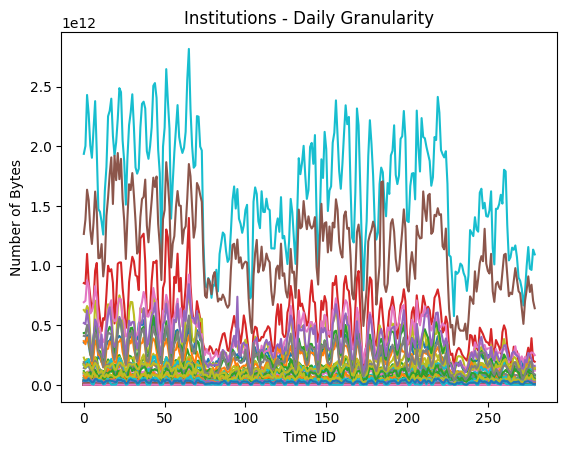

In [3]:
import matplotlib.pyplot as plt
import numpy as np
#analise dos dados diários
inst = []
p_d = 0
val_null = 0
var_z = 0
val_neg = 0
out = 0
for i in df_day["id_institution"].unique():
    instituicao = df_day[df_day["id_institution"]==i]
    serve = True
    Q1 = instituicao["n_bytes"].quantile(0.20)
    Q3 = instituicao["n_bytes"].quantile(0.80)
    IQR = Q3 - Q1
    L_inferior = Q1 - 1.5*IQR
    L_superior = Q3 + 1.5*IQR

    #verifica se ha instituições com poucos dados e elimina elas se for o caso
    if instituicao.shape[0] < 260:
        #print(f"{i} tem poucos dados")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        p_d += 1

    #verifica se ha instituições com valores nulos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"].isnull()].shape[0]>0:
        #print(f"{i} tem valores nulos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_null += 1

    #verifica se ha instituições com variância zero e elimina elas se for o caso
    elif instituicao["n_bytes"].var() == 0:
        #print(f"{i} tem variância zero")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        var_z += 1

    #verifica se ha instituições com valores negativos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"]<0].shape[0]>0:
        #print(f"{i} tem valores negativos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_neg += 1

    #verifica se ha instituições com outliers (valores muito altos) e elimina elas se for o caso
    elif instituicao[(instituicao["n_bytes"] > L_superior) | (instituicao["n_bytes"] < L_inferior)].shape[0]>0:
        serve = False
        out += 1


    if serve:
        inst.append(i)

print(f"Instituições com poucos dados: {p_d}")
print(f"Instituições com pelo menos 1 nulo: {val_null}")
print(f"Instituições com variância zero: {var_z}")
print(f"Instituições com valores negativos: {val_neg}")
print(f"Instituições com outliers: {out}")
print(f"Instituições restantes: {len(inst)}")
inst.remove('243')
for i in inst:
    instituicao = df_day[df_day["id_institution"]==i]
    
    plt.plot(instituicao["id_time"], instituicao["n_bytes"], label=i)
plt.title(f"Institutions - Daily Granularity")
plt.xlabel("Time ID")
plt.ylabel("Number of Bytes")
plt.show()

df_day = df_day[df_day["id_institution"].isin(inst)]
df_hour = df_hour[df_hour["id_institution"].isin(inst)]
df_10min = df_10min[df_10min["id_institution"].isin(inst)]





  
print()

## Funções tratamento e separação de dados

In [4]:
def complete_id(df):
    df = df.copy()
    
    # 1. Cria um MultiIndex com TODAS as combinações teóricas possíveis 
    # (24 horas * 60 minutos = 1440 linhas por ID)
    ids_unicos = df['ID'].unique()
    horas = range(24)
    minutos = range(6)
    
    # Gera a malha cartesiana (ID x Hora x Minuto)
    multi_idx = pd.MultiIndex.from_product(
        [ids_unicos, horas, minutos], 
        names=['ID', 'hour_id', 'min_id']
    )
    
    # 2. Configura a base atual para usar essas três colunas como índice e remove duplicatas
    # O drop_duplicates evita o erro fatal se a sua base original tiver duas marcações exatas no mesmo minuto
    df = df.drop_duplicates(subset=['ID', 'hour_id', 'min_id'])
    df = df.set_index(['ID', 'hour_id', 'min_id'])
    
    # 3. O REINDEX MÁGICO: Ele vai criar as linhas em branco para as horas/minutos que não existem
    df_full = df.reindex(multi_idx).reset_index()
    
    # 4. Preenchimento (Fill)
    # Primeiro agrupa pelo ID para garantir que o bfill/ffill de uma instituição/dia não vaze para outra
    def preencher_gaps(g):
        # Garante a ordem cronológica
        g = g.sort_values(['hour_id', 'min_id'])
        
        # Preenche a id_institution 
        if 'id_institution' in g.columns:
            g['id_institution'] = g['id_institution'].ffill().bfill()
            
        # Preenche as colunas de bytes (ajuste os nomes conforme sua base)
        if 'n_bytes_hour' in g.columns:
            g['n_bytes_hour'] = g['n_bytes_hour'].ffill().bfill()
        if 'n_bytes_10minutes' in g.columns:
            g['n_bytes_10minutes'] = g['n_bytes_10minutes'].ffill().bfill()
            
        # Preenche o resto (exceto as chaves de índice)
        for col in g.columns:
            if col not in ['ID', 'hour_id', 'min_id', 'id_institution', 'n_bytes_hour', 'n_bytes_10minutes']:
                g[col] = g[col].ffill().bfill()
                
        return g

    # Aplica o preenchimento por grupo (por ID)
    df_out = df_full.groupby('ID', group_keys=False).apply(preencher_gaps)
    
    return df_out.reset_index(drop=True)

def treino_val_teste(df = pd.Series, t_treino = 0, t_teste = 0, t_val = 0):
    return  df[:int(t_treino*len(df))], df[int(t_treino*len(df)):int((t_treino + t_val)*len(df))]  , df[int((t_treino + t_val)*len(df)):]

def scaling(df_series: pd.Series, mode = 0, scaler = None) -> pd.Series:
    if mode == 0:
        scaler = MinMaxScaler()
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.fit_transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name),scaler
    elif mode == 1:
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name)     

def sliding_window (df_series: pd.Series, inputs: int, outputs: int, step: int = 1) -> pd.DataFrame:

    total_window_size = inputs + outputs
    
    # 1. Validação
    if len(df_series) < total_window_size:
        print(f"Erro: Tamanho dos dados ({len(df_series)}) é menor que a janela total ({total_window_size})")
        return pd.DataFrame() # Retorna um DataFrame vazio

    # 2. Cria as janelas (sliding windows)
    windowed_data = []
    # Itera do primeiro índice inicial possível até o último
    for i in range(0, len(df_series) - total_window_size + 1, step):
        # A fatia vai de 'i' até 'i + tamanho_total'
        window_slice = df_series.iloc[i : i + total_window_size].values
        windowed_data.append(window_slice)

    # 3. Define os nomes das colunas
    x_cols = [f"x_{j}" for j in range(inputs)]
    y_cols = [f"y_{o}" for o in range(outputs)]
    
    # 4. Cria o DataFrame final
    df_windowed = pd.DataFrame(windowed_data, columns=x_cols + y_cols)
    return df_windowed


## Tratamento de dados faltantes

In [5]:
time_day = pd.read_csv('../../data/times/times_1_day.csv')
time_hour = pd.read_csv('../../data/times/times_1_hour.csv')
time_minute = pd.read_csv('../../data/times/times_10_minutes.csv')

df_day["id_time"] = df_day["id_time"].astype(int)
df_hour["id_time"] = df_hour["id_time"].astype(int)
df_10min["id_time"] = df_10min["id_time"].astype(int)

df_day = df_day.merge(time_day, on="id_time", how="left")
df_day["time"] = pd.to_datetime(df_day["time"])
df_day["time_day"] = df_day["time"].dt.date
df_day["ID"] = df_day["id_institution"].astype(str) + "_" + df_day["time_day"].astype(str)
df_day.drop(columns=["id_time", "time"], inplace=True)

df_hour = df_hour.merge(time_hour, on="id_time", how="left")
df_hour["time"] = pd.to_datetime(df_hour["time"])
df_hour["time_day"] = df_hour["time"]
df_hour["time_day"] = df_hour["time_day"].dt.date
df_hour["ID"] = df_hour["id_institution"].astype(str) + "_" + df_hour["time_day"].astype(str)
df_hour["hour_id"] = pd.to_datetime(df_hour["time"]).dt.hour
df_hour.drop(columns=["id_time", "time", "id_institution"], inplace=True)

df_10min = df_10min.merge(time_minute, on="id_time", how="left")
df_10min["time"] = pd.to_datetime(df_10min["time"], utc = True)
df_10min["ID"] = df_10min["id_institution"].astype(str) + "_" + (df_10min["time"].dt.date).astype(str)
df_10min["min_id"] = df_10min["time"].dt.minute
df_10min["min_id"] = df_10min["min_id"].astype(int)
df_10min["min_id"] = df_10min["min_id"] // 10
df_10min["sec_id"] = df_10min["time"].dt.second
df_10min.drop(columns=["id_time", "time", "id_institution"], inplace=True)

df_merged = df_day.merge(df_hour, on="ID", how="left", suffixes=("_day", "_hour"))
df_merged = df_merged.merge(df_10min, on = "ID", how = "left", suffixes = ("_day", "_10min"))
df_merged.drop(columns=["time_day_hour", "time_day_day"], inplace=True)
df_merged.rename(columns={"n_bytes": "n_bytes_10minutes"}, inplace = True)

df_completo = complete_id(df_merged)

df_day = df_completo[["ID", "id_institution", "n_bytes_day"]].drop_duplicates().copy()
df_day.rename(columns={"n_bytes_day": "n_bytes"}, inplace=True)
df_hour = df_completo[["ID", "id_institution", "hour_id", "n_bytes_hour"]].drop_duplicates().copy()
df_hour.rename(columns={"n_bytes_hour": "n_bytes"}, inplace=True)
df_hour["ID"] = df_hour["ID"] + "_" + df_hour["hour_id"].astype(str)
df_hour.drop(columns=["hour_id"], inplace=True)
df_10min = df_completo[["id_institution", "hour_id","min_id", "n_bytes_10minutes"]].drop_duplicates().copy()
df_10min.rename(columns={"n_bytes_10minutes": "n_bytes"}, inplace=True)


/tmp/ipykernel_86843/2901186231.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_out = df_full.groupby('ID', group_keys=False).apply(preencher_gaps)


## Tratando [DIA] e separando em treino, val e teste

In [8]:


inputs_day = 7
outputs_day = 1
x_cols = [f"x_{j}" for j in range(inputs_day)]
y_cols = [f"y_{o}" for o in range(outputs_day)]
train_list = []
val_list = []
test_list = []
train_list_1d = []
test_list_1d = [] 
val_list_1d = []
for i in inst:
    print(i)
    serie = pd.Series(df_day[df_day["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_day + outputs_day):
        _train_day, _val_day, _test_day  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_day,scaler = scaling(_train_day,0)
        test_day = scaling(_test_day,1,scaler)
        val_day = scaling(_val_day,1,scaler)

        train_day_ = sliding_window(df_series = train_day, inputs = inputs_day, outputs = outputs_day)
        train_day_.insert(0, "id_institution", i)
        train_list.append(train_day_)

        test_day_ = sliding_window(df_series = test_day, inputs = inputs_day, outputs = outputs_day)
        test_day_.insert(0, "id_institution", i)
        test_list.append(test_day_)

        val_day_ = sliding_window(df_series = val_day, inputs = inputs_day, outputs = outputs_day)
        val_day_.insert(0, "id_institution", i)
        val_list.append(val_day_)

    else: print(f"   dataset pequeno ({tamanho})")
train_day_wind = pd.concat(train_list, ignore_index=True)
val_day_wind = pd.concat(val_list, ignore_index=True)
test_day_wind = pd.concat(test_list, ignore_index=True)
inst_day = list(train_day_wind["id_institution"].unique())
print("\n\n" + str(len(inst_day)))
del train_list, val_list, test_list
train_day_wind.to_csv('../../data/Tabelas_criadas/treino_dia.csv', index = False)
test_day_wind.to_csv('../../data/Tabelas_criadas/teste_dia.csv', index = False)
val_day_wind.to_csv('../../data/Tabelas_criadas/val_dia.csv', index = False)


68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


101


In [10]:
# O '.joblib' ou '.pkl' são extensões padrão para esse tipo de arquivo
caminho_arquivo = '../scalers/scalers_day.joblib'

inputs_day = 7
outputs_day = 1
x_cols = [f"x_{j}" for j in range(inputs_day)]
y_cols = [f"y_{o}" for o in range(outputs_day)]
scalers_day = {}
for i in inst:
    serie = pd.Series(df_day[df_day["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_day + outputs_day):
        _train_day, _val_day, _test_day  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_day,scaler = scaling(_train_day,0)
        test_day = scaling(_test_day,1,scaler)
        val_day = scaling(_val_day,1,scaler)
        scalers_day[i] = scaler

# Salva o seu dicionário inteiro de uma só vez
joblib.dump(scalers_day, caminho_arquivo)

['../scalers/scalers_day.joblib']

## Tratando [HORAS] e separando em treino, val e teste

In [9]:


inputs_hour = 7*24
outputs_hour = 1*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_hour[df_hour["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_hour,scaler = scaling(_train_hour,0)
        test_hour = scaling(_test_hour,1,scaler)
        val_hour = scaling(_val_hour,1,scaler)
        train_hour_ = sliding_window(df_series = train_hour, inputs = inputs_hour, outputs = outputs_hour)
        train_hour_.insert(0, "id_institution", i)
        train_list.append(train_hour_)

        test_hour_ = sliding_window(df_series = test_hour, inputs = inputs_hour, outputs = outputs_hour)
        test_hour_.insert(0, "id_institution", i)
        test_list.append(test_hour_)

        val_hour_ = sliding_window(df_series = val_hour, inputs = inputs_hour, outputs = outputs_hour)
        val_hour_.insert(0, "id_institution", i)
        val_list.append(val_hour_)
    else: print(f"   dataset pequeno ({tamanho})")

train_hour_wind = pd.concat(train_list, ignore_index=True)
val_hour_wind = pd.concat(val_list, ignore_index=True)
test_hour_wind = pd.concat(test_list, ignore_index=True)


train_hour_wind.to_csv('../../data/Tabelas_criadas/treino_hora.csv', index = False)
test_hour_wind.to_csv('../../data/Tabelas_criadas/teste_hora.csv', index = False)
val_hour_wind.to_csv('../../data/Tabelas_criadas/val_hora.csv', index = False)

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


In [10]:


inputs_hour = 7*24
outputs_hour = 1*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_hour[df_hour["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_hour,scaler = scaling(_train_hour,0)
        test_hour = scaling(_test_hour,1,scaler)
        val_hour = scaling(_val_hour,1,scaler)
        train_hour_ = sliding_window(df_series = train_hour, inputs = inputs_hour, outputs = outputs_hour, step=24)
        train_hour_.insert(0, "id_institution", i)
        train_list.append(train_hour_)

        test_hour_ = sliding_window(df_series = test_hour, inputs = inputs_hour, outputs = outputs_hour, step=24)
        test_hour_.insert(0, "id_institution", i)
        test_list.append(test_hour_)

        val_hour_ = sliding_window(df_series = val_hour, inputs = inputs_hour, outputs = outputs_hour, step=24)
        val_hour_.insert(0, "id_institution", i)
        val_list.append(val_hour_)
    else: print(f"   dataset pequeno ({tamanho})")

train_hour_wind = pd.concat(train_list, ignore_index=True)
val_hour_wind = pd.concat(val_list, ignore_index=True)
test_hour_wind = pd.concat(test_list, ignore_index=True)


train_hour_wind.to_csv('../../data/Tabelas_criadas/treino_hora_steped.csv', index = False)
test_hour_wind.to_csv('../../data/Tabelas_criadas/teste_hora_steped.csv', index = False)
val_hour_wind.to_csv('../../data/Tabelas_criadas/val_hora_steped.csv', index = False)

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


In [11]:

caminho_arquivo = '../scalers/scalers_hour.joblib'
inputs_hour = 7*24
outputs_hour = 1*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]
train_list_1d = []
test_list_1d = [] 
val_list_1d = []
scalers_hour = {}
for i in inst:
    serie = pd.Series(df_hour[df_hour["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_hour,scaler = scaling(_train_hour,0)
        test_hour = scaling(_test_hour,1,scaler)
        val_hour = scaling(_val_hour,1,scaler)
        scalers_hour[i] = scaler

joblib.dump(scalers_hour, caminho_arquivo)

['../scalers/scalers_hour.joblib']

## Tratando [MINUTOS] e separando em treino, val e teste
por enquano, este vai ficar de escanteio por precisar de um tratamento mais especifico


In [11]:


inputs_10min = 2*24*6
outputs_10min = 1*24*6
x_cols = [f"x_{j}" for j in range(inputs_10min)]
y_cols = [f"y_{o}" for o in range(outputs_10min)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_10min[df_10min["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_10min + outputs_10min):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_10min,scaler = scaling(_train_hour,0)
        test_10min = scaling(_test_hour,1,scaler)
        val_10min = scaling(_val_hour,1,scaler)
        train_10min_ = sliding_window(df_series = train_10min, inputs = inputs_10min, outputs = outputs_10min)
        train_10min_["id_institution"] = i
        train_list.append(train_10min_)

        test_10min_ = sliding_window(df_series = test_10min, inputs = inputs_10min, outputs = outputs_10min)
        test_10min_["id_institution"] = i
        test_list.append(test_10min_)
        val_10min_ = sliding_window(df_series = val_10min, inputs = inputs_10min, outputs = outputs_10min)
        val_10min_["id_institution"] = i
        val_list.append(val_10min_)
    else: print(f"   dataset pequeno ({tamanho})")

train_10min_wind = pd.concat(train_list, ignore_index=True)
val_10min_wind = pd.concat(val_list, ignore_index=True)
test_10min_wind = pd.concat(test_list, ignore_index=True)
inst_10min = list(train_10min_wind["id_institution"].unique())
print("\n\n" + str(len(inst_10min)))


train_10min_wind.to_csv('../../data/Tabelas_criadas/treino_10min.csv', index = False)
test_10min_wind.to_csv('../../data/Tabelas_criadas/teste_10min.csv', index = False)
val_10min_wind.to_csv('../../data/Tabelas_criadas/val_10min.csv', index = False)

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


101


In [12]:

caminho_arquivo = '../scalers/scalers_10min.joblib'

inputs_10min = 2*24*6
outputs_10min = 1*24*6
x_cols = [f"x_{j}" for j in range(inputs_10min)]
y_cols = [f"y_{o}" for o in range(outputs_10min)]
train_list = []
val_list = []
test_list = []
scalers_10min = {}
for i in inst:
    print(i)
    serie = pd.Series(df_10min[df_10min["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_10min + outputs_10min):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_10min,scaler = scaling(_train_hour,0)

        scalers_10min[i] = scaler

joblib.dump(scalers_10min, caminho_arquivo)

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


['../scalers/scalers_10min.joblib']

## Dados já carregados

### Dia

In [57]:


train_day_wind = pd.read_csv('../../data/Tabelas_criadas/treino_dia.csv')
test_day_wind = pd.read_csv('../../data/Tabelas_criadas/teste_dia.csv')
val_day_wind = pd.read_csv('../../data/Tabelas_criadas/val_dia.csv')
inputs_day = 7
outputs_day = 1

np_train_d = np.array(train_day_wind)
np_test_d = np.array(test_day_wind)
np_val_d = np.array(val_day_wind)
X_train_d = np_train_d[:, :inputs_day + 1].astype('float32')
y_train_d = np_train_d[:, inputs_day+1:].astype('float32')
X_test_d = np_test_d[:, :inputs_day + 1].astype('float32')
y_test_d = np_test_d[:, np.r_[inputs_day+1:inputs_day+1+y_train_d.shape[1],0]].astype('float32')
X_val_d = np_val_d[:, :inputs_day + 1].astype('float32')
y_val_d = np_val_d[:, inputs_day+1:].astype('float32')



### Hora

In [58]:
train_hour_wind = pd.read_csv('../../data/Tabelas_criadas/treino_hora.csv')
test_hour_wind = pd.read_csv('../../data/Tabelas_criadas/teste_hora.csv')
val_hour_wind = pd.read_csv('../../data/Tabelas_criadas/val_hora.csv')
inputs_hour = 7*24
outputs_hour = 1*24

np_train_h = np.array(train_hour_wind)
np_test_h = np.array(test_hour_wind)
np_val_h = np.array(val_hour_wind)
X_train_h = np_train_h[:, :inputs_hour + 1].astype('float32')
y_train_h = np_train_h[:, inputs_hour+1:].astype('float32')
X_test_h = np_test_h[:, :inputs_hour + 1].astype('float32')
y_test_h = np_test_h[:, np.r_[inputs_hour+1:inputs_hour+1+y_train_h.shape[1],0]].astype('float32')
X_val_h = np_val_h[:, :inputs_hour + 1].astype('float32')
y_val_h = np_val_h[:, inputs_hour+1:].astype('float32')

### Horas com step 24

In [9]:
train_hour_wind = pd.read_csv('../../data/Tabelas_criadas/treino_hora_steped.csv')
test_hour_wind = pd.read_csv('../../data/Tabelas_criadas/teste_hora_steped.csv')
val_hour_wind = pd.read_csv('../../data/Tabelas_criadas/val_hora_steped.csv')
inputs_hour = 7*24
outputs_hour = 1*24

np_train_h = np.array(train_hour_wind)
np_test_h = np.array(test_hour_wind)
np_val_h = np.array(val_hour_wind)
X_train_h = np_train_h[:, :inputs_hour + 1].astype('float32')
y_train_h = np_train_h[:, inputs_hour+1:].astype('float32')
X_test_h = np_test_h[:, :inputs_hour + 1].astype('float32')
y_test_h = np_test_h[:, np.r_[inputs_hour+1:inputs_hour+1+y_train_h.shape[1],0]].astype('float32')
X_val_h = np_val_h[:, :inputs_hour + 1].astype('float32')
y_val_h = np_val_h[:, inputs_hour+1:].astype('float32')

## Funções de modelos preditivos

In [59]:
# For Graphs plotting and training time evaluation
import pylab as plt

def generate_GRU(n_timesteps, n_features, n_outputs, dropout_rate=0.2, gru_units=64):
    """
    Cria um modelo GRU puro.
    
    n_timesteps: Comprimento da sequência temporal (no seu caso, 1)
    n_features: Quantidade de colunas/variáveis de entrada
    n_outputs: Quantidade de valores a prever
    """
    
    # Camada de Entrada
    inp = Input(shape=(n_timesteps, n_features))
    x = GRU_layer(gru_units, return_sequences=False)(inp) 
    
    # Dropout para evitar overfitting
    x = Dropout(dropout_rate)(x)
    out = Dense(n_outputs, activation='linear')(x)
    
    model = Model(inputs=inp, outputs=out)
    return model



from statsmodels.tsa.statespace.sarimax import SARIMAX

def generate_SARIMA_model(order, seasonal_order, X_train):
    """
    Cria um modelo SARIMA com os parâmetros fornecidos.
    
    order: tupla (p,d,q)
    seasonal_order: tupla (P,D,Q,s)
    X_train: série temporal de treino
    """
    model = SARIMAX(
        X_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model

def generate_MLP_model(input_len, output, dropout_rate=0.2, dense_units=500, layers=3):
    ip = Input(shape=(input_len,))
    y= Dropout(0.1)(ip)
    y = Flatten()(y)
    for _ in range(layers):
        y = Dense(dense_units, activation='relu')(y)
        y = Dropout(dropout_rate)(y)
    out = Dense(output, activation='linear')(y)
    model = Model(ip, out)

    return model

def generate_LSTM(n_timesteps, 
                  n_features, 
                  n_outputs, 
                  dropout_rate=0.2, 
                  lstm_units=64
                  ):
    inp = Input(shape=(n_timesteps, n_features))
    x = LSTM_layer(lstm_units, return_sequences=False)(inp) 
    x = Dropout(dropout_rate)(x)
    out = Dense(n_outputs, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    return model

def generate_RNN(n_timesteps, 
                 n_features, 
                 n_outputs, 
                 dropout_rate=0.2, 
                 rnn_units=64
                 ):
    inp = Input(shape=(n_timesteps, n_features))
    x = RNN_layer(rnn_units, return_sequences=False)(inp) 
    x = Dropout(dropout_rate)(x)
    out = Dense(n_outputs, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    return model

def get_nrmse(global_range):
    def nrmse(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Calcular o RMSE matematicamente
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        rmse = tf.sqrt(mse)
        
        # Usa a amplitude global fixa em vez de calcular por lote!
        return rmse / global_range
    
    # Renomeia a função interna para ficar bonito no log do Keras
    nrmse.__name__ = 'nrmse'
    return nrmse

def smape(y_true, y_pred):
    y_true = cast(y_true, float32)
    y_pred = cast(y_pred, float32)
    diff = abs(y_true - y_pred)
    add = abs(y_true) + abs(y_pred)
    # epsilon é usado para evitar divisão por zero
    return 100.0 * reduce_mean(diff / maximum(add, epsilon()))

In [60]:
def criar_e_treinarMLP(dimensao,
                       input_len, 
                       output_len,
                       dropout_rate,
                        dense_units,
                        layers,
                       X_train,y_train, 
                       X_val, 
                       y_val, 
                       epochs, 
                       batch_size, 
                       path_modelo = None, 
                       path_metricas = None,
                       plot = True,
                       verbose = True
                       ):
    print("criando modelo...")
    mlp = generate_MLP_model(input_len,output_len, dropout_rate=dropout_rate, dense_units=dense_units, layers=layers)
    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())
    mlp.compile(
        optimizer='adam',
        loss='mean_squared_error', # Para regressão, a perda é o MSE
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(amplitude_global),
                smape
            ]
    )
    print("treinando modelo...")
    history = mlp.fit(
        X_train, 
        y_train, 
        epochs=epochs, # Comece com poucas epochs (ex: 10) e aumente se necessário
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    if verbose:
        print(
            f"modelo treinado!\
            \nResultado:\
            \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
            \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
            \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
            \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
            )
    
    if plot:
        plt.title(label= 'MLP Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='MLP Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='MLP Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='MLP Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        mlp.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": "MLP"
            ,"DIM": dimensao
            ,"RMSE": history.history["val_rmse"][-1]
            ,"MAE": history.history["val_mae"][-1]
            ,"NMRSE": history.history['val_nrmse'][-1]
            ,"SMAPE": history.history['val_smape'][-1]
            }

        df = pd.DataFrame(dict_model).set_index("idx")
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarGRU(dimensao,
                       input_len, 
                       output_len,
                       X_train,
                       y_train,
                        X_val,
                        y_val,
                        epochs,
                        batch_size,
                        dropout_rate, 
                        gru_units, 
                        path_modelo = None, 
                        path_metricas = None,
                        plot = True,
                        verbose = True):
    print("criando modelo...")
    gru = generate_GRU(1,input_len,output_len, dropout_rate, gru_units)

    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())

    gru.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(amplitude_global),
                smape
            ]
    )
    if len(X_train.shape) == 2:
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
        X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = gru.fit(
        X_train, 
        y_train, 
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    if verbose:
        print(
            f"modelo treinado!\
            \nResultado:\
            \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
            \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
            \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
            \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
            )
    
    if plot:
        plt.title(label= 'GRU Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='GRU Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='GRU Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='GRU Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        gru.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": ["GRU"]
            ,"DIM": [dimensao]
            ,"RMSE": [history.history["val_rmse"][-1]]
            ,"MAE": [history.history["val_mae"][-1]]
            ,"NMRSE": [history.history['val_nrmse'][-1]]
            ,"SMAPE": [history.history['val_smape'][-1]]
            }

        df = pd.DataFrame(dict_model)
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarLSTM(dimensao,
                       input_len, 
                       output_len,
                       X_train,
                       y_train,
                        X_val,
                        y_val,
                        epochs,
                        batch_size,
                        dropout_rate, 
                       lstm_units, 
                       path_modelo = None, 
                       path_metricas = None,
                       plot = True,
                       verbose = True):
    print("criando modelo...")
    lstm = generate_LSTM(1,input_len, output_len, dropout_rate, lstm_units)

    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())

    lstm.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(amplitude_global),
                smape
            ]
    )
    if len(X_train.shape) == 2:
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
        X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = lstm.fit(
        X_train, 
        y_train, 
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    if verbose:
        print(
            f"modelo treinado!\
            \nResultado:\
            \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
            \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
            \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
            \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
            )
    
    if plot:
        plt.title(label= 'LSTM Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='LSTM Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='LSTM Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='LSTM Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        lstm.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": ["LSTM"]
            ,"DIM": [dimensao]
            ,"RMSE": [history.history["val_rmse"][-1]]
            ,"MAE": [history.history["val_mae"][-1]]
            ,"NMRSE": [history.history['val_nrmse'][-1]]
            ,"SMAPE": [history.history['val_smape'][-1]]
            }

        df = pd.DataFrame(dict_model)
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarRNN(dimensao,
                          input_len, 
                          output_len,
                          X_train,
                          y_train,
                            X_val,
                            y_val,
                            epochs,
                            batch_size,
                            dropout_rate, 
                          rnn_units, 
                          path_modelo = None, 
                          path_metricas = None,
                          plot = True,
                          verbose = True):
    print("criando modelo...")
    rnn = generate_RNN(
         n_timesteps = 1,
         n_features=input_len,
         n_outputs = output_len,
         dropout_rate = dropout_rate,
         rnn_units = rnn_units
    )
    
    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())
    
    rnn.compile(
          optimizer='adam',
          loss='mean_squared_error',
          metrics=[
                 RootMeanSquaredError(name='rmse'),
                 MeanAbsoluteError(name='mae'),
                 get_nrmse(amplitude_global),
                 smape
                ]
     )
    if len(X_train.shape) == 2:
          X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
          X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = rnn.fit(
          X_train, 
          y_train, 
          epochs=epochs,
          batch_size=batch_size,
          validation_data=(X_val, y_val),
          verbose=0
     )
    if verbose:
          print(
                f"modelo treinado!\
                \nResultado:\
                \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
                \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
                \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
                \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
                )
     
    if plot:
          plt.title(label= 'RNN Val RMSE')
          plt.plot(history.history['val_rmse'])
          plt.show()
          plt.title(label='RNN Val MAE')
          plt.plot(history.history['val_mae'])
          plt.show()
          plt.title(label='RNN Val NRMSE')
          plt.plot(history.history['val_nrmse'])
          plt.show()
          plt.title(label='RNN Val SMAPE')
          plt.plot(history.history['val_smape'])
          plt.show()
    if path_modelo is not None:
          rnn.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
            dict_model ={
                "idx": 0
                ,"MODELO": ["RNN"]
                ,"DIM": [dimensao]
                ,"RMSE": [history.history["val_rmse"][-1]]
                ,"MAE": [history.history["val_mae"][-1]]
                ,"NMRSE": [history.history['val_nrmse'][-1]]
                ,"SMAPE": [history.history['val_smape'][-1]]
                }
    
            df = pd.DataFrame(dict_model)
            header_condition = not os.path.exists(path_metricas)
            df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

## Funções de treinadmento dos modelos

In [61]:
def otimizar_GRU(X_train, 
                 y_train, 
                 X_val, 
                 y_val, 
                 dimensao, 
                 input_len, 
                 output_len,
                 path_modelo = None):
    
    def objective(trial):
        # 1. Definir o espaço de busca que será passado para a sua função
        # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        epochs = trial.suggest_int('epochs', 10, 30, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
        gru_units = trial.suggest_int('gru_units', 32, 128)
        
        try:
            # Chama a SUA função
            history = criar_e_treinarGRU(
                dimensao=dimensao,
                input_len=input_len,
                output_len=output_len,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                dropout_rate=dropout_rate,
                gru_units=gru_units,
                path_modelo= None,
                plot=False,
                verbose=False
)
            return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
            
        except Exception as e:
            # Poda o teste se a rede explodir (NaN) ou der erro
            raise optuna.exceptions.TrialPruned()

    # 2. Criar e rodar o estudo
    study = optuna.create_study(direction='minimize', study_name="Otimizacao_GRU")
    study.optimize(objective, n_trials=20) # Define quantas variações testar

    print(f"\nMelhor NRMSE: {study.best_value}")
    print(f"Melhores parâmetros: {study.best_params}")
    criar_e_treinarGRU(
        dimensao=dimensao,
        input_len=input_len,
        output_len=output_len,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=study.best_params['epochs'],
        batch_size=study.best_params['batch_size'],
        dropout_rate=study.best_params['dropout_rate'],
        gru_units=study.best_params['gru_units'],
        path_modelo=path_modelo,
        plot=True
    )
    return study

def otimizar_LSTM(X_train, 
                 y_train, 
                 X_val, 
                 y_val, 
                 dimensao, 
                 input_len, 
                 output_len,
                 path_modelo = None):
    
    def objective(trial):
        # 1. Definir o espaço de busca que será passado para a sua função
        # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        epochs = trial.suggest_int('epochs', 10, 30, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
        lstm_units = trial.suggest_int('lstm_units', 32, 128)
        
        try:
            # Chama a SUA função
            history = criar_e_treinarLSTM(
                dimensao=dimensao,
                input_len=input_len,
                output_len=output_len,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                dropout_rate=dropout_rate,
                lstm_units=lstm_units,
                path_modelo= None,
                plot=False,
                verbose=False
)
            return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
            
        except Exception as e:
            # Poda o teste se a rede explodir (NaN) ou der erro
            raise optuna.exceptions.TrialPruned()

    # 2. Criar e rodar o estudo
    study = optuna.create_study(direction='minimize', study_name="Otimizacao_LSTM")
    study.optimize(objective, n_trials=20) # Define quantas variações testar

    print(f"\nMelhor NRMSE: {study.best_value}")
    print(f"Melhores parâmetros: {study.best_params}")
    criar_e_treinarLSTM(
        dimensao=dimensao,
        input_len=input_len,
        output_len=output_len,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=study.best_params['epochs'],
        batch_size=study.best_params['batch_size'],
        dropout_rate=study.best_params['dropout_rate'],
        lstm_units=study.best_params['lstm_units'],
        path_modelo=path_modelo,
        plot=True
    )
    return study

def otimizar_RNN(X_train,
                    y_train, 
                    X_val, 
                    y_val, 
                    dimensao, 
                    input_len, 
                    output_len,
                    path_modelo = None):
        
        def objective(trial):
            # 1. Definir o espaço de busca que será passado para a sua função
            # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
            epochs = trial.suggest_int('epochs', 10, 30, step=10)
            dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
            rnn_units = trial.suggest_int('rnn_units', 32, 128)
            
            try:
                # Chama a SUA função
                history = criar_e_treinarRNN(
                    dimensao=dimensao,
                    input_len=input_len,
                    output_len=output_len,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    epochs=epochs,
                    batch_size=batch_size,
                    dropout_rate=dropout_rate,
                    rnn_units=rnn_units,
                    path_modelo= None,
                    plot=False,
                    verbose=False
    )
                return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
                
            except Exception as e:
                # Poda o teste se a rede explodir (NaN) ou der erro
                raise optuna.exceptions.TrialPruned()
    
        # 2. Criar e rodar o estudo
        study = optuna.create_study(direction='minimize', study_name="Otimizacao_RNN")
        study.optimize(objective, n_trials=20) # Define quantas variações testar
    
        print(f"\nMelhor NRMSE: {study.best_value}")
        print(f"Melhores parâmetros: {study.best_params}")
        criar_e_treinarRNN(
            dimensao=dimensao,
            input_len=input_len,
            output_len=output_len,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            epochs=study.best_params['epochs'],
            batch_size=study.best_params['batch_size'],
            dropout_rate=study.best_params['dropout_rate'],
            rnn_units=study.best_params['rnn_units'],
            path_modelo=path_modelo,
            plot=True
        )
        return study


def otimizar_MLP(X_train, 
                 y_train, 
                 X_val, 
                 y_val, 
                 dimensao, 
                 input_len, 
                 output_len,
                 path_modelo = None):
    
    def objective(trial):
        # 1. Definir o espaço de busca que será passado para a sua função
        # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        epochs = trial.suggest_int('epochs', 10, 30, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
        dense_units = trial.suggest_int('dense_units', 100, 500)
        layers = trial.suggest_int('layers', 1, 3)
        
        try:
            # Chama a SUA função
            history = criar_e_treinarMLP(
                dimensao=dimensao,
                input_len=input_len,
                output_len=output_len,
                dropout_rate=dropout_rate,
                dense_units=dense_units,
                layers=layers,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                path_modelo= None,
                plot=False,
                verbose=False
)
            return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
            
        except Exception as e:
            # Poda o teste se a rede explodir (NaN) ou der erro
            raise optuna.exceptions.TrialPruned()

    # 2. Criar e rodar o estudo
    study = optuna.create_study(direction='minimize', study_name="Otimizacao_MLP")
    study.optimize(objective, n_trials=20) # Define quantas variações testar

    print(f"\nMelhor NRMSE: {study.best_value}")
    print(f"Melhores parâmetros: {study.best_params}")
    criar_e_treinarMLP(
        dimensao=dimensao,
        input_len=input_len,
        output_len=output_len,
        dropout_rate=study.best_params['dropout_rate'],
        dense_units=study.best_params['dense_units'],
        layers=study.best_params['layers'],
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=study.best_params['epochs'],
        batch_size=study.best_params['batch_size'],
        path_modelo=path_modelo,
        plot=True
    )
    return study

## Treinar modelos

[I 2026-03-10 11:43:24,586] A new study created in memory with name: Otimizacao_GRU
E0000 00:00:1773153804.682719    5055 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773153804.691781    5055 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 11:43:33,590] Trial 0 finished with value: 0.16443967819213867 and parameters: {'batch_size': 64, 'epochs': 10, 'dropout_rate': 0.275578498817561, 'gru_units': 64}. Best is trial 0 with value: 0.16443967819213867.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 11:43:46,116] Trial 1 finished with value: 0.16106493771076202 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.4167068183675692, 'gru_units': 35}. Best is trial 1 with value: 0.16106493771076202.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 11:57:13,517] Trial 18 finished with value: 0.15887637436389923 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.2168405018914949, 'gru_units': 58}. Best is trial 14 with value: 0.15805542469024658.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 11:57:26,878] Trial 19 finished with value: 0.16351991891860962 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.4499726901444935, 'gru_units': 40}. Best is trial 14 with value: 0.15805542469024658.



Melhor NRMSE: 0.15805542469024658
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.341154708479368, 'gru_units': 32}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.157791867852211   val:0.17038847506046295            
MAE:
    teste:0.1179942861199379   val:0.1246194988489151            
NRMSE:
  teste:0.15343593060970306   val:0.1594342440366745            
SMAPE:
  teste:25.367345809936523   val:27.7258243560791


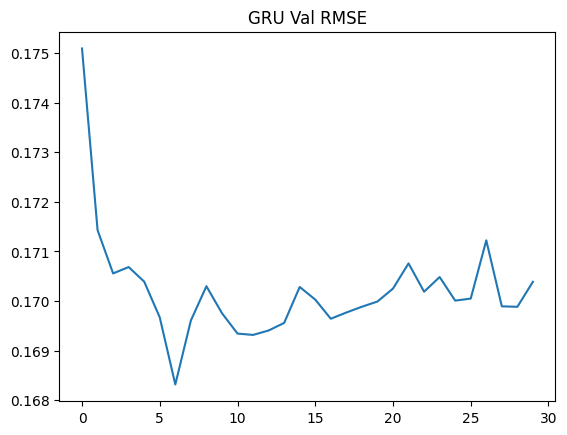

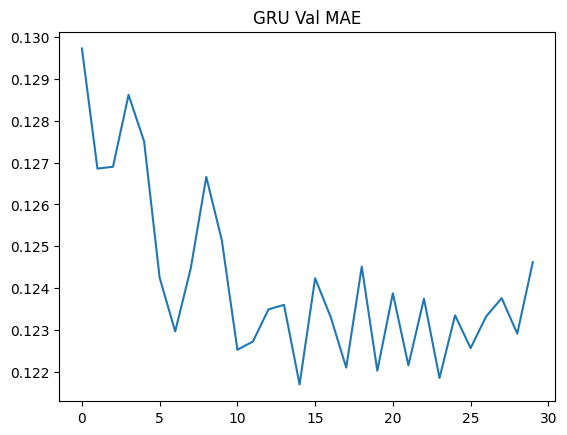

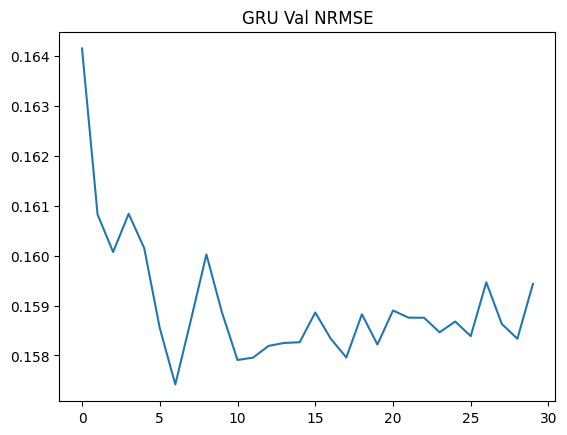

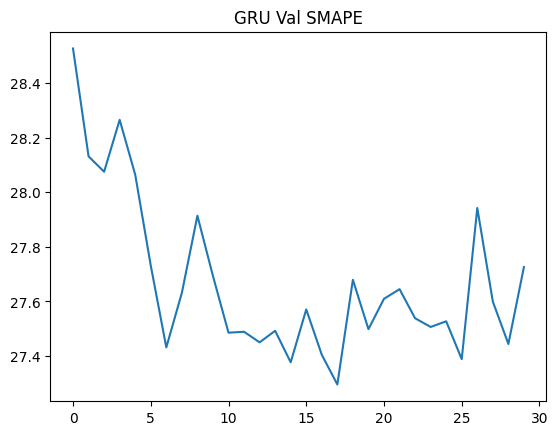

In [10]:
study_d_sid = otimizar_GRU(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo='gru_diaria_otimizada_sem_id.keras')

In [ ]:
study_d = otimizar_GRU(X_train_d, 
                        y_train_d, 
                        X_val_d, 
                        y_val_d, 
                        "diária", 
                        inputs_day+1, 
                        outputs_day,
                        path_modelo='gru_diaria_otimizada.keras')

[I 2026-03-10 12:07:33,209] A new study created in memory with name: Otimizacao_GRU


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 12:16:16,471] Trial 0 finished with value: 0.054315656423568726 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.12235538230555863, 'gru_units': 73}. Best is trial 0 with value: 0.054315656423568726.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 12:22:00,917] Trial 1 finished with value: 0.05461956188082695 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.3592900955266286, 'gru_units': 91}. Best is trial 0 with value: 0.054315656423568726.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 16:09:57,144] Trial 18 finished with value: 0.0517883226275444 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.15934442271761623, 'gru_units': 89}. Best is trial 11 with value: 0.05129585042595863.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 16:31:47,765] Trial 19 finished with value: 0.05158064514398575 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.2344269170484726, 'gru_units': 126}. Best is trial 11 with value: 0.05129585042595863.



Melhor NRMSE: 0.05129585042595863
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.23200401989248848, 'gru_units': 125}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.06664243340492249   val:0.06513845175504684            
MAE:
    teste:0.03866652771830559   val:0.0345926359295845            
NRMSE:
  teste:0.06545303761959076   val:0.051436156034469604            
SMAPE:
  teste:41.97629928588867   val:39.145503997802734


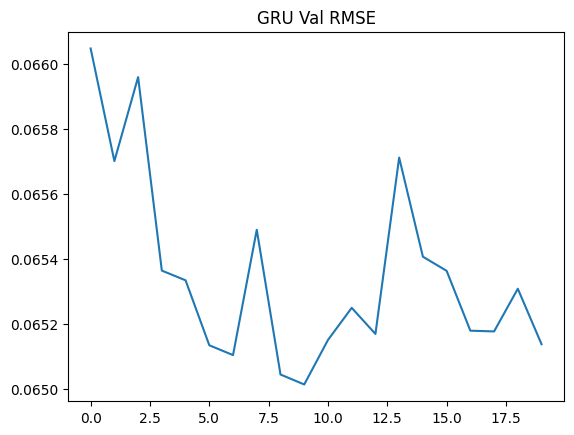

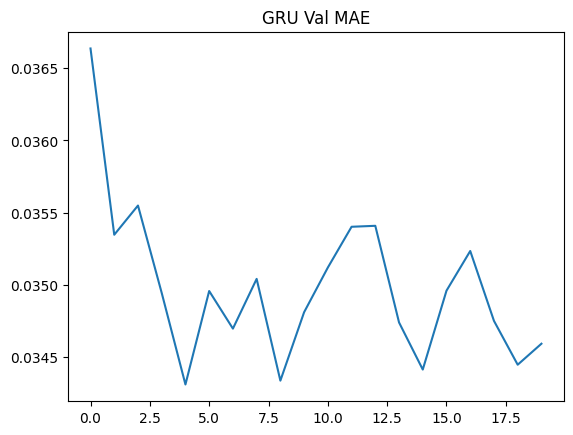

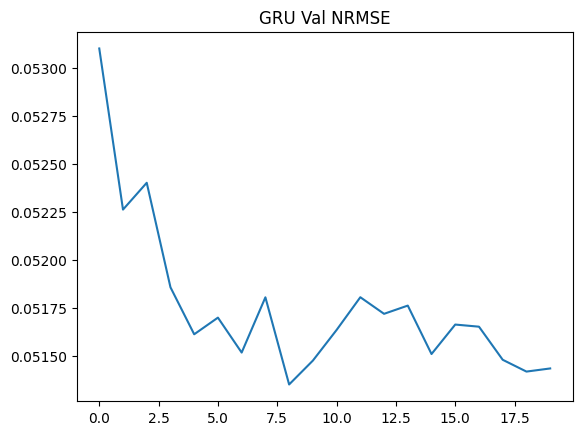

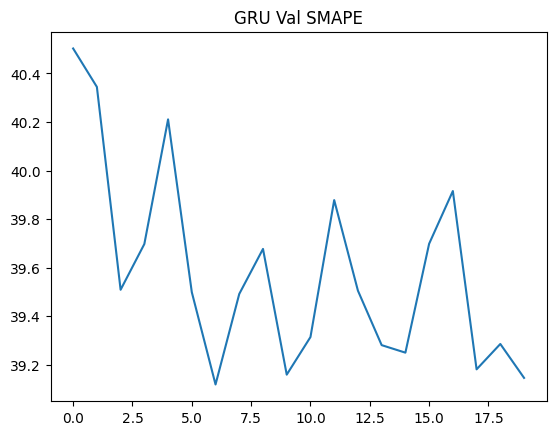

In [13]:
study_h_sid = otimizar_GRU(X_train_h[:,1:], 
                       y_train_h, 
                       X_val_h[:,1:], 
                       y_val_h, 
                       "horária", 
                       inputs_hour,
                       outputs_hour,
                       path_modelo= 'gru_horaria_otimizada_sem_id.keras')

In [ ]:
study_h = otimizar_GRU(X_train_h, 
                       y_train_h, 
                       X_val_h, 
                       y_val_h, 
                       "horária", 
                       inputs_hour+1,
                       outputs_hour,
                       path_modelo= 'gru_horaria_otimizada.keras')

[I 2026-03-08 12:29:03,592] A new study created in memory with name: Otimizacao_GRU


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 12:43:32,191] Trial 0 finished with value: 0.053839121013879776 and parameters: {'batch_size': 16, 'epochs': 50, 'dropout_rate': 0.43514317372010325, 'gru_units': 38}. Best is trial 0 with value: 0.053839121013879776.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 12:46:53,962] Trial 1 finished with value: 0.053716111928224564 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.39820049844988603, 'gru_units': 78}. Best is trial 1 with value: 0.053716111928224564.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 15:45:28,367] Trial 18 finished with value: 0.05327552184462547 and parameters: {'batch_size': 16, 'epochs': 50, 'dropout_rate': 0.25956335507710704, 'gru_units': 89}. Best is trial 17 with value: 0.052590757608413696.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 15:48:43,602] Trial 19 finished with value: 0.05541747808456421 and parameters: {'batch_size': 64, 'epochs': 40, 'dropout_rate': 0.32372068530860193, 'gru_units': 68}. Best is trial 17 with value: 0.052590757608413696.



Melhor NRMSE: 0.052590757608413696
Melhores parâmetros: {'batch_size': 16, 'epochs': 40, 'dropout_rate': 0.2368420652728273, 'gru_units': 107}


[I 2026-03-11 12:14:33,469] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:15:15,379] Trial 0 finished with value: 0.16384625434875488 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.3732663027084887, 'rnn_units': 49}. Best is trial 0 with value: 0.16384625434875488.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:15:46,064] Trial 1 finished with value: 0.1667569875717163 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.3142835947331143, 'rnn_units': 66}. Best is trial 0 with value: 0.16384625434875488.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:23:01,552] Trial 18 finished with value: 0.16545821726322174 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.14295742973399447, 'rnn_units': 80}. Best is trial 12 with value: 0.16348589956760406.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:23:44,449] Trial 19 finished with value: 0.1634034514427185 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.1482807508794411, 'rnn_units': 126}. Best is trial 19 with value: 0.1634034514427185.



Melhor NRMSE: 0.1634034514427185
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.1482807508794411, 'rnn_units': 126}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.16753913462162018   val:0.1748548150062561                
MAE:
    teste:0.1272725611925125   val:0.13047267496585846                
NRMSE:
  teste:0.16352954506874084   val:0.16416889429092407                
SMAPE:
  teste:26.264907836914062   val:28.597862243652344


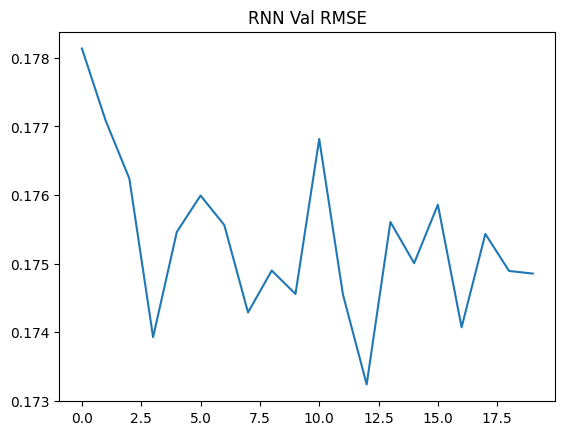

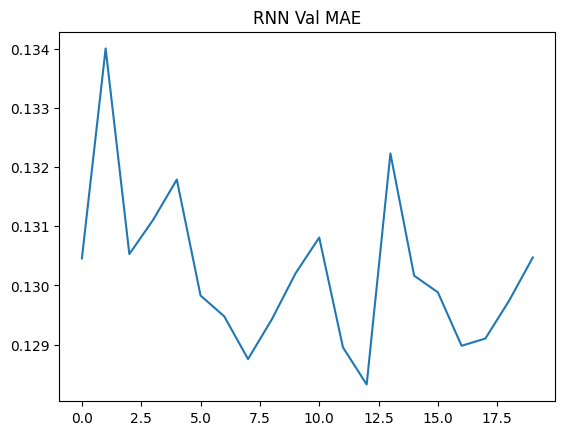

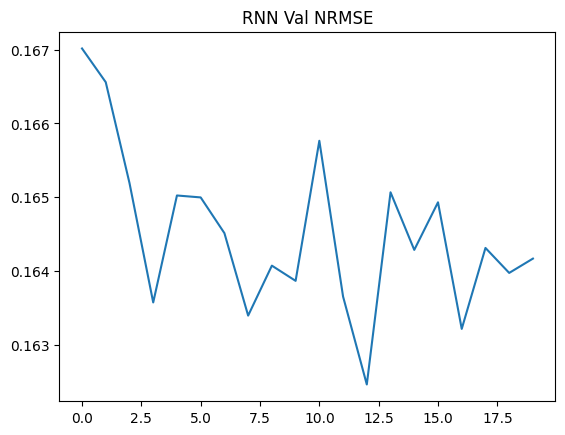

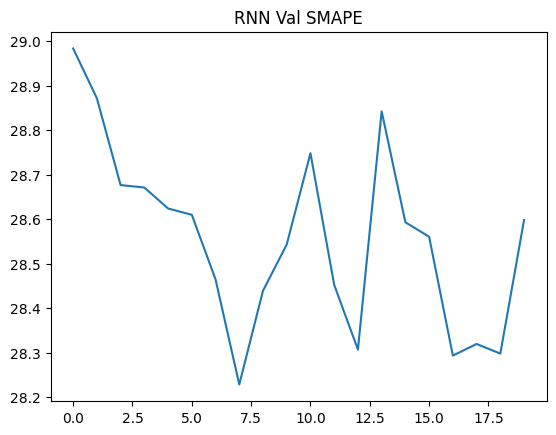

In [35]:
rnn_study_d_sid = otimizar_RNN(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo='rnn_diaria_otimizada_sem_id.keras')

[I 2026-03-11 12:02:59,431] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:03:15,843] Trial 0 finished with value: 0.1717298924922943 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.4239314519816536, 'rnn_units': 40}. Best is trial 0 with value: 0.1717298924922943.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:03:58,629] Trial 1 finished with value: 0.16706883907318115 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.4866081722492681, 'rnn_units': 95}. Best is trial 1 with value: 0.16706883907318115.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:13:07,448] Trial 18 finished with value: 0.16502588987350464 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.24567468142445983, 'rnn_units': 66}. Best is trial 9 with value: 0.16216875612735748.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:13:52,361] Trial 19 finished with value: 0.16198229789733887 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.15104423182253793, 'rnn_units': 85}. Best is trial 19 with value: 0.16198229789733887.



Melhor NRMSE: 0.16198229789733887
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.15104423182253793, 'rnn_units': 85}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.1707954853773117   val:0.17285600304603577                
MAE:
    teste:0.13054491579532623   val:0.12533079087734222                
NRMSE:
  teste:0.16676627099514008   val:0.1620478332042694                
SMAPE:
  teste:26.92116355895996   val:27.887861251831055


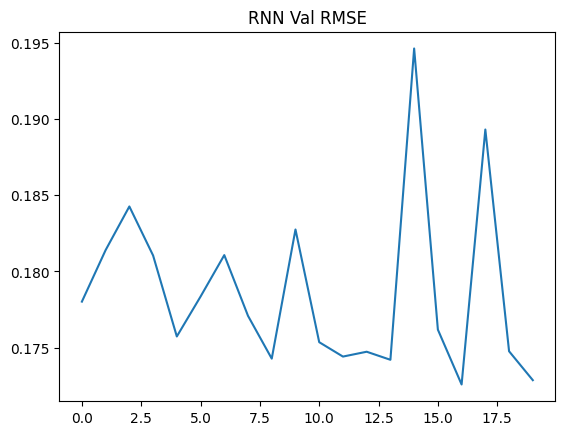

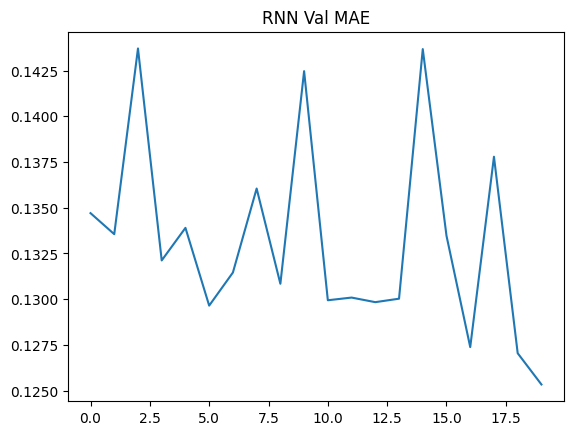

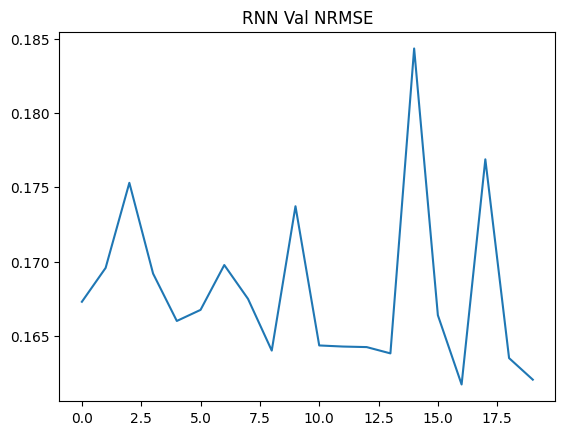

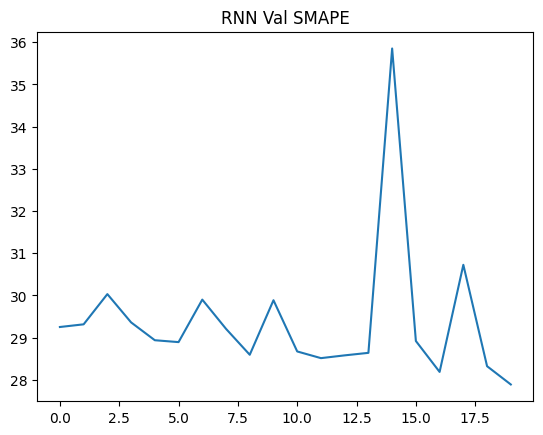

In [34]:
rnn_study_d = otimizar_RNN(X_train_d, 
                        y_train_d, 
                        X_val_d, 
                        y_val_d, 
                        "diária", 
                        inputs_day+1, 
                        outputs_day,
                        path_modelo='rnn_diaria_otimizada.keras')

[I 2026-03-12 12:32:50,576] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 12:39:04,707] Trial 0 finished with value: 0.058991048485040665 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.2588008504461772, 'rnn_units': 68}. Best is trial 0 with value: 0.058991048485040665.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 12:50:38,533] Trial 1 finished with value: 0.05559791624546051 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.1698115088093946, 'rnn_units': 40}. Best is trial 1 with value: 0.05559791624546051.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 15:37:41,108] Trial 18 finished with value: 0.05608998239040375 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.3756247474093184, 'rnn_units': 61}. Best is trial 16 with value: 0.055467620491981506.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 15:45:25,188] Trial 19 finished with value: 0.055440474301576614 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.10154836132072385, 'rnn_units': 74}. Best is trial 19 with value: 0.055440474301576614.



Melhor NRMSE: 0.055440474301576614
Melhores parâmetros: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.10154836132072385, 'rnn_units': 74}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.07106995582580566   val:0.06802591681480408                
MAE:
    teste:0.04262228310108185   val:0.03878491744399071                
NRMSE:
  teste:0.06995110213756561   val:0.05528311803936958                
SMAPE:
  teste:44.32145309448242   val:42.014427185058594


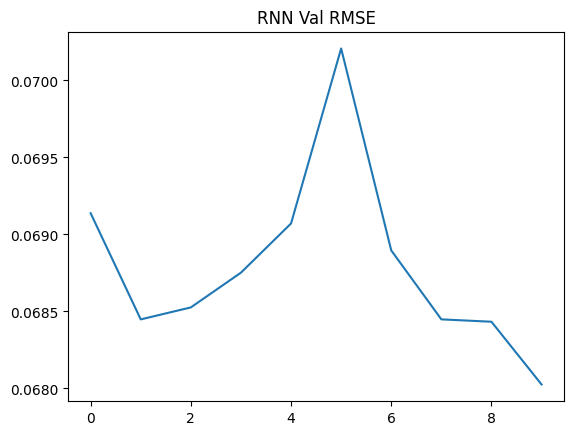

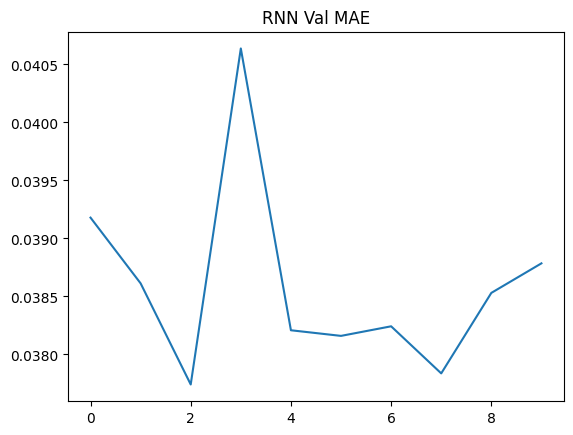

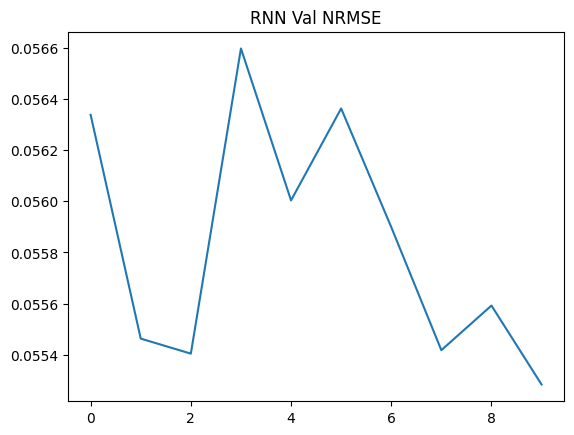

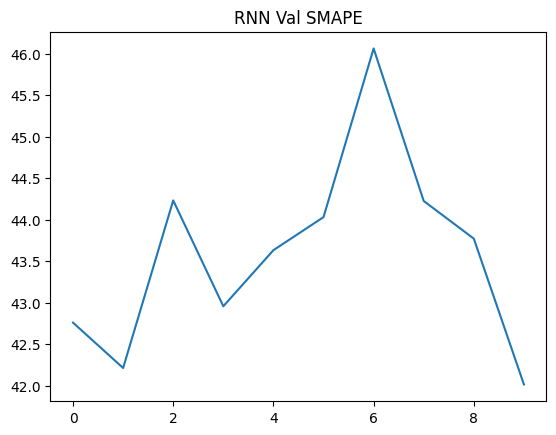

In [74]:
rnn_study_h_sem_id = otimizar_RNN(
                          X_train_h[:,1:], 
                          y_train_h, 
                          X_val_h[:,1:], 
                          y_val_h, 
                          "horária", 
                          inputs_hour,
                          outputs_hour,
                          path_modelo= ('rnn_horaria_otimizada_sem_id.keras')
)

[I 2026-03-11 15:50:10,632] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 16:01:08,576] Trial 0 finished with value: 0.05732583627104759 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.3963504255796704, 'rnn_units': 39}. Best is trial 0 with value: 0.05732583627104759.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 16:13:15,753] Trial 1 finished with value: 0.05737536773085594 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.1154539389042884, 'rnn_units': 108}. Best is trial 0 with value: 0.05732583627104759.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 19:34:35,733] Trial 18 finished with value: 0.05920702591538429 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.44035204146310414, 'rnn_units': 44}. Best is trial 4 with value: 0.05676921084523201.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 19:43:09,791] Trial 19 finished with value: 0.0592099130153656 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.3673296124168392, 'rnn_units': 128}. Best is trial 4 with value: 0.05676921084523201.



Melhor NRMSE: 0.05676921084523201
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.470698131925946, 'rnn_units': 126}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.07801507413387299   val:0.072028249502182                
MAE:
    teste:0.05097087845206261   val:0.04678900167346001                
NRMSE:
  teste:0.07696525007486343   val:0.06141923740506172                
SMAPE:
  teste:49.52189636230469   val:45.876380920410156


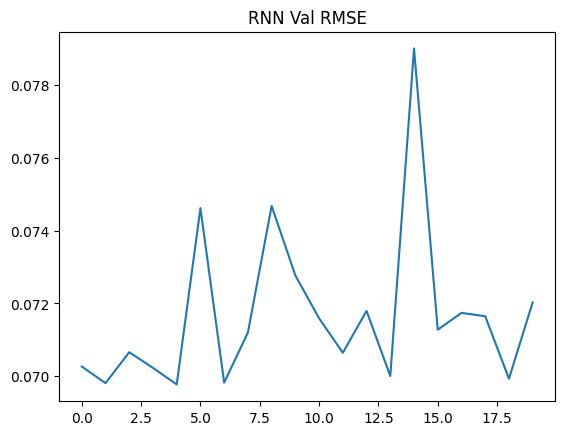

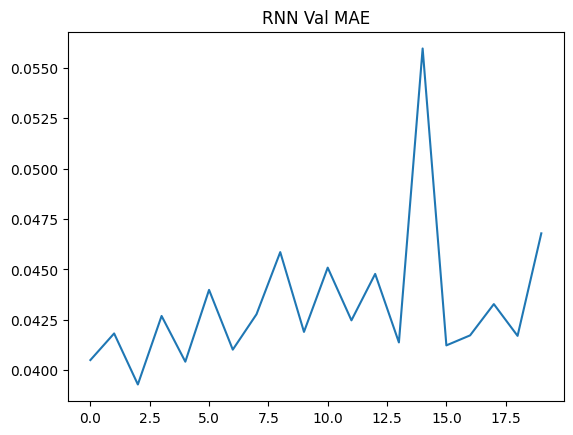

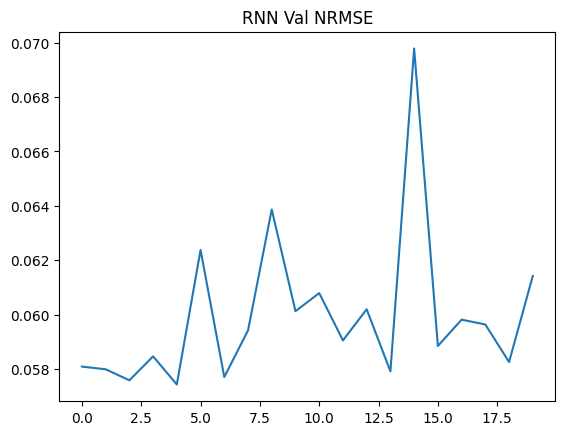

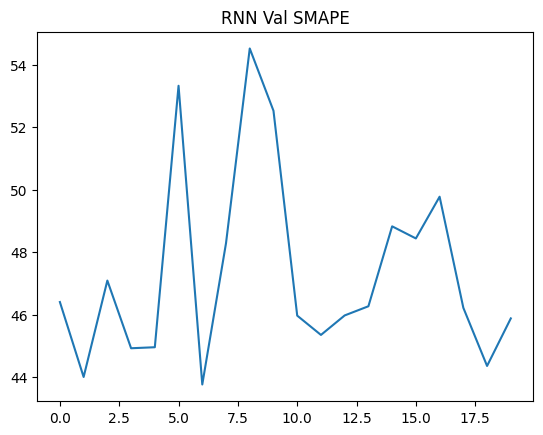

In [ ]:
rnn_study_h = otimizar_RNN(
                          X_train_h, 
                          y_train_h, 
                          X_val_h, 
                          y_val_h, 
                          "horária", 
                          inputs_hour+1,
                          outputs_hour,
                          path_modelo= ('rnn_horaria_otimizada.keras')
)

[I 2026-03-11 20:00:01,791] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:00:33,510] Trial 0 finished with value: 0.1623040735721588 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.22075544749918802, 'lstm_units': 37}. Best is trial 0 with value: 0.1623040735721588.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:00:55,725] Trial 1 finished with value: 0.16499808430671692 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.3303455966809999, 'lstm_units': 84}. Best is trial 0 with value: 0.1623040735721588.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:09:01,878] Trial 18 finished with value: 0.15865913033485413 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.4980949050121251, 'lstm_units': 33}. Best is trial 8 with value: 0.15780316293239594.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:09:46,408] Trial 19 finished with value: 0.15946680307388306 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.4190405203300016, 'lstm_units': 49}. Best is trial 8 with value: 0.15780316293239594.



Melhor NRMSE: 0.15780316293239594
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.30494559354849515, 'lstm_units': 35}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.15744514763355255   val:0.17019547522068024            
MAE:
    teste:0.11736654490232468   val:0.12515734136104584            
NRMSE:
  teste:0.15289001166820526   val:0.15928901731967926            
SMAPE:
  teste:25.16774559020996   val:27.633922576904297


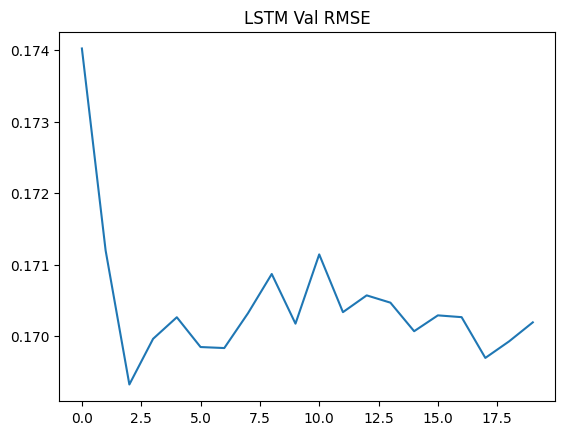

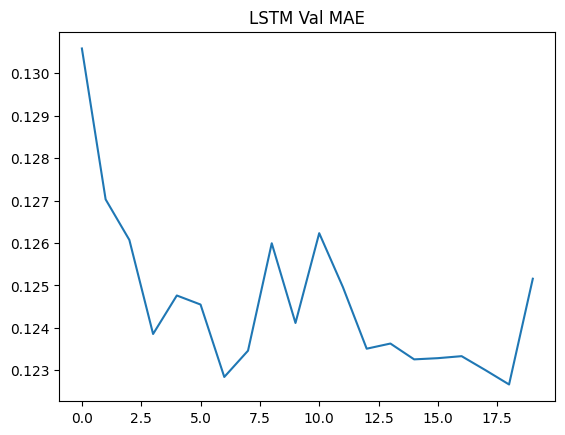

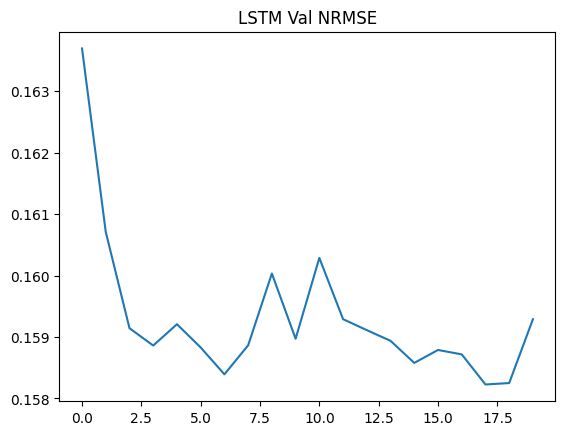

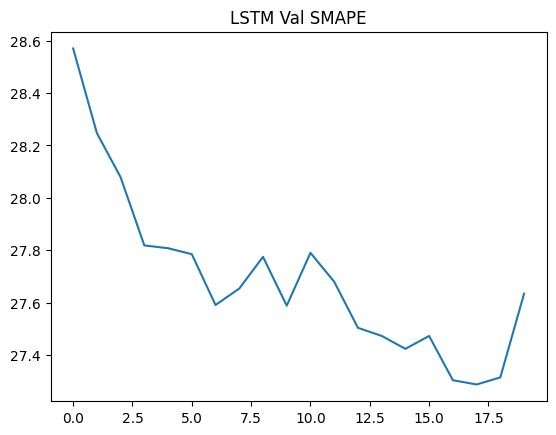

In [40]:
lstm_study_d_sid = otimizar_LSTM(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo='lstm_diaria_otimizada_sem_id.keras'
                        )

[I 2026-03-11 20:10:24,565] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:11:47,127] Trial 0 finished with value: 0.1634022742509842 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.15980893943695793, 'lstm_units': 110}. Best is trial 0 with value: 0.1634022742509842.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:12:10,903] Trial 1 finished with value: 0.164828360080719 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.4853763821976457, 'lstm_units': 104}. Best is trial 0 with value: 0.1634022742509842.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:21:32,620] Trial 18 finished with value: 0.16106747090816498 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.22204628283421946, 'lstm_units': 40}. Best is trial 10 with value: 0.16052716970443726.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:22:47,177] Trial 19 finished with value: 0.15926241874694824 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.1723553408367834, 'lstm_units': 89}. Best is trial 19 with value: 0.15926241874694824.



Melhor NRMSE: 0.15926241874694824
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.1723553408367834, 'lstm_units': 89}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.16245120763778687   val:0.17252880334854126            
MAE:
    teste:0.1226717159152031   val:0.12810297310352325            
NRMSE:
  teste:0.15825429558753967   val:0.16240060329437256            
SMAPE:
  teste:25.822240829467773   val:28.13339614868164


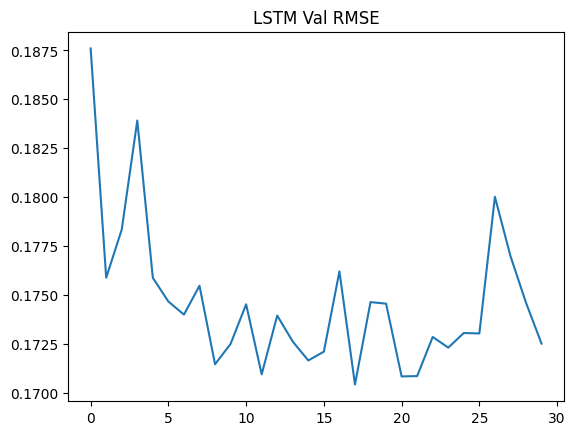

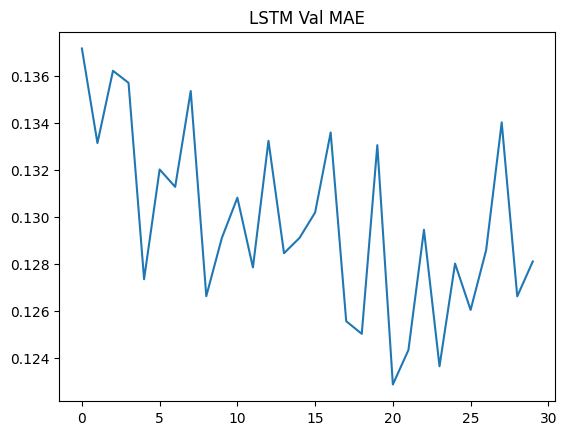

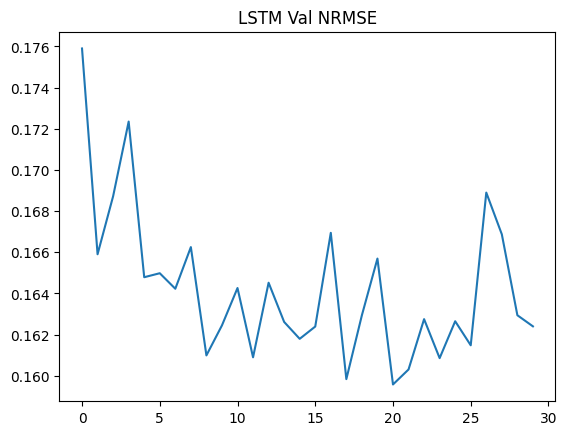

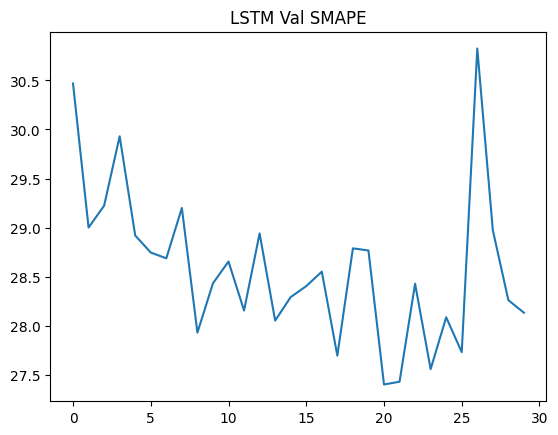

In [41]:
lstm_study_d = otimizar_LSTM(X_train_d, 
                        y_train_d, 
                        X_val_d, 
                        y_val_d, 
                        "diária", 
                        inputs_day+1, 
                        outputs_day,
                        path_modelo='lstm_diaria_otimizada.keras'
                        )

[I 2026-03-11 20:24:04,637] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:35:27,418] Trial 0 finished with value: 0.052036695182323456 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.33548712867644187, 'lstm_units': 82}. Best is trial 0 with value: 0.052036695182323456.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:48:43,654] Trial 1 finished with value: 0.05333587899804115 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.48471367628419404, 'lstm_units': 103}. Best is trial 0 with value: 0.052036695182323456.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 00:27:26,672] Trial 18 finished with value: 0.05200572311878204 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.13570057807497282, 'lstm_units': 115}. Best is trial 13 with value: 0.05127556249499321.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 00:39:11,277] Trial 19 finished with value: 0.051785361021757126 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.22088916928224467, 'lstm_units': 71}. Best is trial 13 with value: 0.05127556249499321.



Melhor NRMSE: 0.05127556249499321
Melhores parâmetros: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.12232294709305555, 'lstm_units': 123}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.06590858101844788   val:0.06615141034126282            
MAE:
    teste:0.03775922954082489   val:0.03467020019888878            
NRMSE:
  teste:0.06472348421812057   val:0.051982391625642776            
SMAPE:
  teste:40.87458038330078   val:39.511566162109375


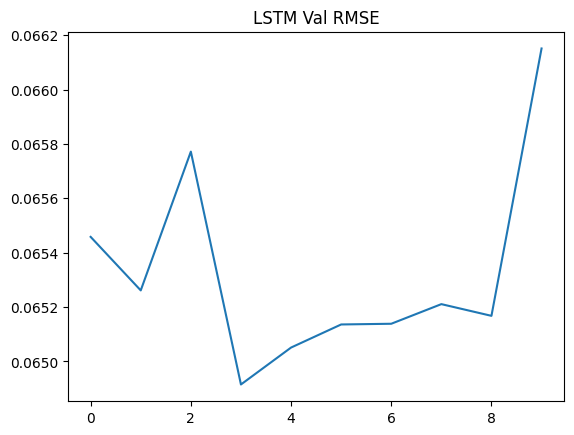

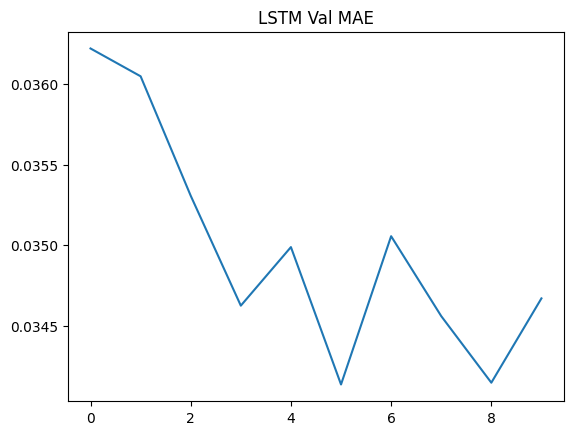

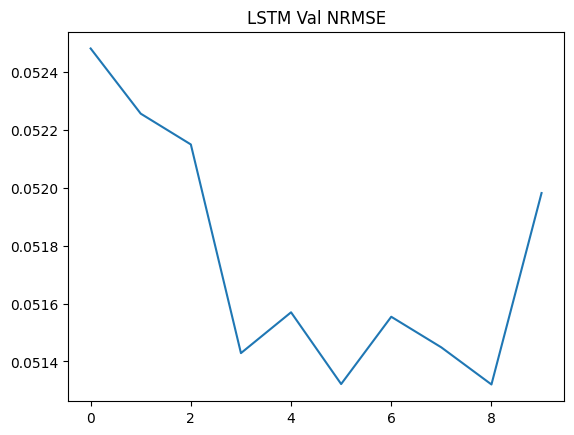

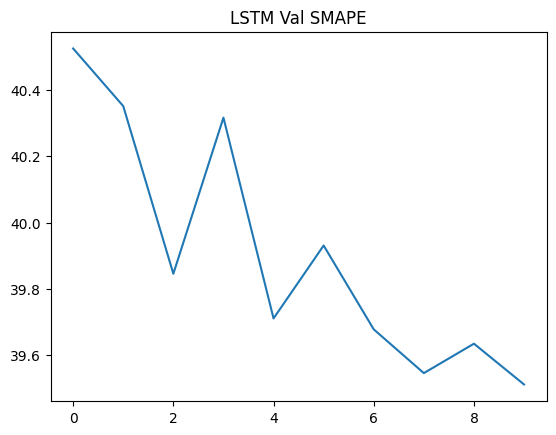

In [42]:
lstm_study_h_sid = otimizar_LSTM(
                          X_train_h[:,1:], 
                          y_train_h, 
                          X_val_h[:,1:],
                            y_val_h,
                            "horária",
                            inputs_hour,
                            outputs_hour,
                            path_modelo= 'lstm_horaria_otimizada_sem_id.keras'
)

[I 2026-03-12 15:52:52,460] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 16:00:51,176] Trial 0 finished with value: 0.055381786078214645 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.10706437937871015, 'lstm_units': 38}. Best is trial 0 with value: 0.055381786078214645.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 16:04:14,170] Trial 1 finished with value: 0.05572722852230072 and parameters: {'batch_size': 64, 'epochs': 10, 'dropout_rate': 0.1734682177924025, 'lstm_units': 82}. Best is trial 0 with value: 0.055381786078214645.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 22:12:53,328] Trial 18 finished with value: 0.05554687976837158 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.49326220263706844, 'lstm_units': 100}. Best is trial 11 with value: 0.05275715887546539.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 22:49:13,205] Trial 19 finished with value: 0.05308590829372406 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.15698380289593336, 'lstm_units': 119}. Best is trial 11 with value: 0.05275715887546539.



Melhor NRMSE: 0.05275715887546539
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.10217578756711457, 'lstm_units': 107}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.06752781569957733   val:0.06627672165632248            
MAE:
    teste:0.0397660955786705   val:0.03582075238227844            
NRMSE:
  teste:0.06636197119951248   val:0.05273425579071045            
SMAPE:
  teste:42.638648986816406   val:41.42425537109375


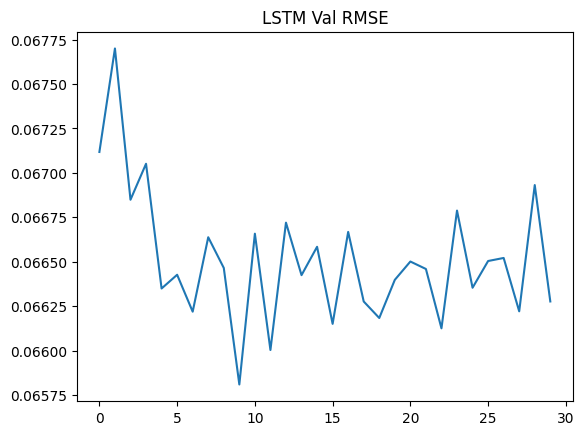

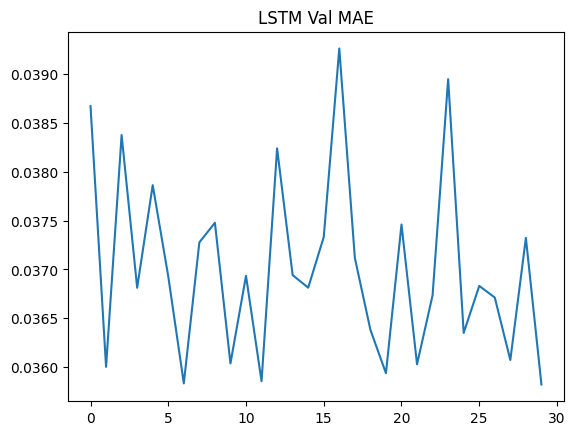

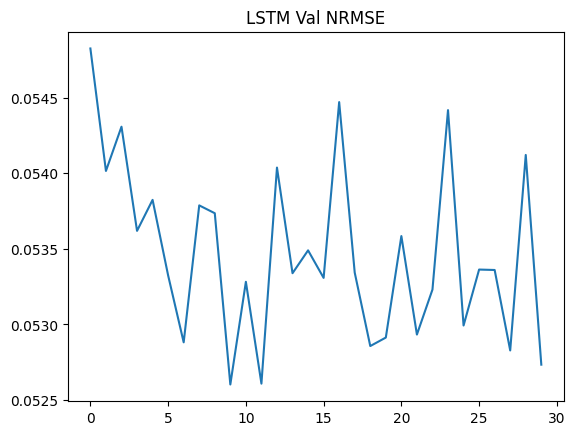

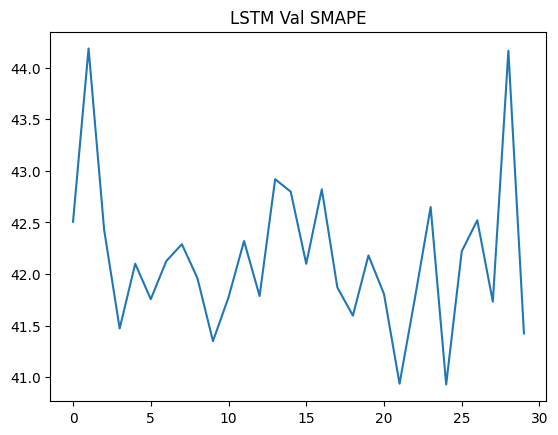

In [75]:
lstm_study_h = otimizar_LSTM(X_train_h,
                            y_train_h,
                            X_val_h,
                            y_val_h,
                            "horária",
                            inputs_hour+1,
                            outputs_hour,
                            path_modelo='lstm_horaria_otimizada.keras'
                            )

In [223]:
from keras.models import load_model
dim_keys = ["Horario", "Diario"]
model_keys = ["GRU", "LSTM", "RNN"]

modelos ={
    "GRU":{
        "Diario": load_model('../../MODELOS/gru_diaria_otimizada_sem_id.keras', compile=False),
        "Horario": load_model('../../MODELOS/gru_horaria_otimizada_sem_id.keras', compile=False)
    },
    "LSTM":{
        "Diario": load_model('../../MODELOS/lstm_diaria_otimizada_sem_id.keras', compile=False),
        "Horario": load_model('../../MODELOS/lstm_horaria_otimizada_sem_id.keras', compile=False)
    },
    "RNN":{
        "Diario": load_model('../../MODELOS/rnn_diaria_otimizada_sem_id.keras', compile=False),
        "Horario": load_model('../../MODELOS/rnn_horaria_otimizada_sem_id.keras', compile=False)
    }
}

In [17]:
new_train_d = modelos["GRU"]["Diario"].predict(X_train_d[:,1:].reshape(X_train_d.shape[0], 1, X_train_d.shape[1]-1))
new_train_h = modelos["GRU"]["Horario"].predict(X_train_h[:,1:].reshape(X_train_h.shape[0], 1, X_train_h.shape[1]-1))
new_train_c = np.hstack((new_train_d, new_train_h))

new_val_d = modelos["GRU"]["Diario"].predict(X_val_d[:,1:].reshape(X_val_d.shape[0], 1, X_val_d.shape[1]-1))
new_val_h = modelos["GRU"]["Horario"].predict(X_val_h[:,1:].reshape(X_val_h.shape[0], 1, X_val_h.shape[1]-1))
new_val_c = np.hstack((new_val_d, new_val_h))

new_test_d = modelos["GRU"]["Diario"].predict(X_test_d[:,1:].reshape(X_test_d.shape[0], 1, X_test_d.shape[1]-1))
new_test_h = modelos["GRU"]["Horario"].predict(X_test_h[:,1:].reshape(X_test_h.shape[0], 1, X_test_h.shape[1]-1))
new_test_c = np.hstack((new_test_d, new_test_h))

841/841 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step
841/841 ━━━━━━━━━━━━━━━━━━━━ 1s 636us/step
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step


[I 2026-03-18 16:30:45,548] A new study created in memory with name: Otimizacao_MLP


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-18 16:31:00,044] Trial 0 finished with value: 0.06383540481328964 and parameters: {'batch_size': 64, 'epochs': 10, 'dropout_rate': 0.40645742527514805, 'dense_units': 431, 'layers': 2}. Best is trial 0 with value: 0.06383540481328964.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-18 16:31:39,434] Trial 1 finished with value: 0.06367634236812592 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.32830497104386214, 'dense_units': 497, 'layers': 2}. Best is trial 1 with value: 0.06367634236812592.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-18 16:40:16,281] Trial 18 finished with value: 0.060870684683322906 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.10680750993649157, 'dense_units': 352, 'layers': 1}. Best is trial 17 with value: 0.05965189263224602.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-18 16:40:50,412] Trial 19 finished with value: 0.0603041909635067 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.34992673379784606, 'dense_units': 247, 'layers': 1}. Best is trial 17 with value: 0.05965189263224602.



Melhor NRMSE: 0.05965189263224602
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.14013317548407123, 'dense_units': 328, 'layers': 1}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.06649328023195267   val:0.0676184892654419            
MAE:
    teste:0.038074132055044174   val:0.03815077617764473            
NRMSE:
  teste:0.0653398185968399   val:0.06100514158606529            
SMAPE:
  teste:40.8159065246582   val:42.189002990722656


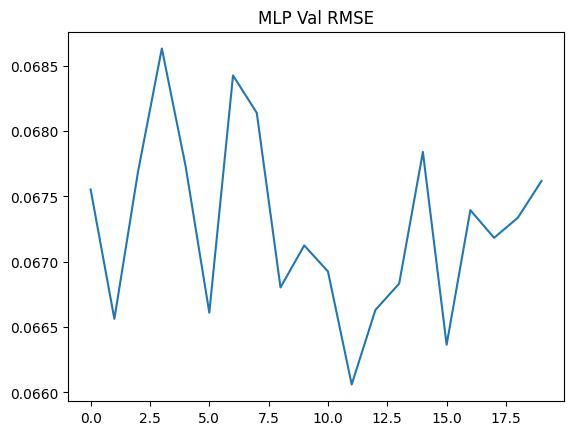

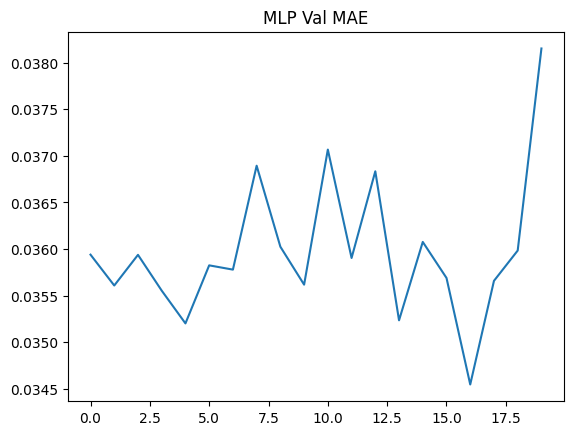

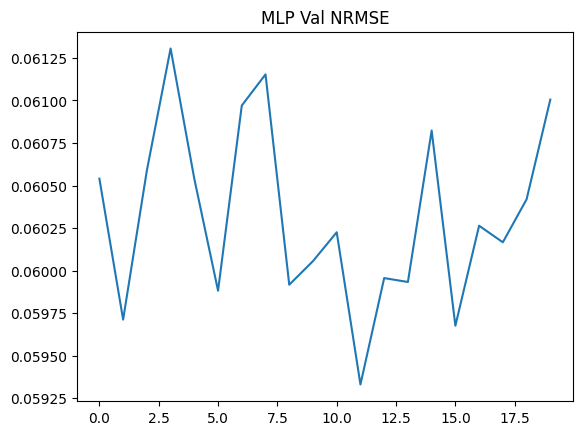

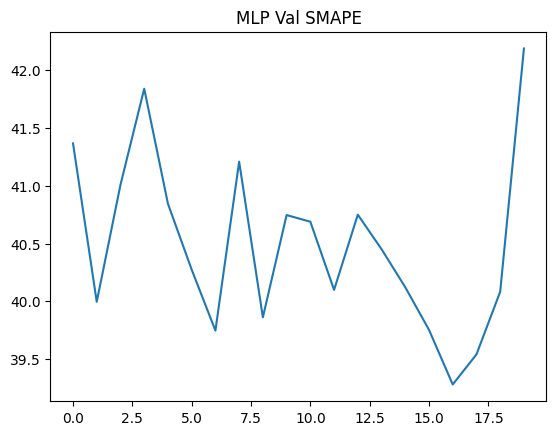

In [45]:
study_mlp_c = otimizar_MLP(new_train_c,
                            y_train_h,
                            new_val_c,
                            y_val_h,
                            "combinada",
                            new_train_c.shape[1],
                            outputs_hour,
                            path_modelo='mlp_combinada_otimizada.keras'
                            )

## Funções de avaliação modelos

In [224]:
from keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

def avaliar_modelo(y_real, y_previsto, verbose = False):
    mse = mean_squared_error(y_real, y_previsto)
    rmse = math.sqrt(mse)
    nrmse = rmse / (max(y_real) - min(y_real))
    mae = mean_absolute_error(y_real, y_previsto)
    _smape = smape(y_real, y_previsto) 
    if verbose:
        print(f"--- Desempenho: ---")
        print(f"RMSE (Erro Médio): {rmse:.4f}")
        print(f"MAE  (Erro Absoluto): {mae:.4f}")
        print(f"SMAPE: {_smape:.4f}")
        print(f"NRMSE: {nrmse:.4f}")
        print("-" * 30)
    return {"RMSE": rmse, "MAE": mae, "NRMSE": nrmse, "SMAPE": _smape}

def comparar_desempeho_granularidade(X_test_d, X_test_h, y_test_d, y_test_h, MODELO_d, MODELO_h):
    print("Carregando modelos...")
    y_pred_d = MODELO_d.predict(X_test_d)
    y_pred_h = MODELO_h.predict(X_test_h)
    
    print(f"Desempenho do modelo para granularidade diária:")
    resultado_d = avaliar_modelo(y_test_d.flatten(), y_pred_d.flatten(), verbose=True)
    
    print(f"Desempenho do modelo para granularidade horária:")
    resultado_h = avaliar_modelo(y_test_h.flatten(), y_pred_h.flatten(), verbose=True)
    
    return {"Diario": resultado_d, "Horario": resultado_h}

def separar_dados_por_instituicao(inst, X_test, y_test =  None):
    idx = np.where(X_test[:,0] == inst)[0]
    X_test_i = X_test[idx]
    if y_test is not None:
        y_test_i = y_test[idx]
        return X_test_i, y_test_i
    else:
        return X_test_i
def avaliar_modelo_inst(inst:list,X_test_d, X_test_h, y_test_d, y_test_h, modelo_d, modelo_h):
    resultados = {
        "instituição": [],
        "granularidade:": [],
        "MAE": [],
        "RMSE": [],
        "NRMSE": [],
        "SMAPE": []
    }
    for i in inst:
        print(f"\n##############################\n \
Avaliando instituição {i}... \
                \n##############################\n")
        X_test_d_i, y_test_d_i = separar_dados_por_instituicao(i, X_test_d, y_test_d)
        X_test_h_i, y_test_h_i = separar_dados_por_instituicao(i, X_test_h, y_test_h)
        resultado = comparar_desempeho_granularidade(X_test_d_i, X_test_h_i, y_test_d_i, y_test_h_i, modelo_d, modelo_h)
        resultados["instituição"].append(i)
        resultados["granularidade:"].append("diária")
        resultados["MAE"].append(resultado["Diario"]["MAE"])
        resultados["RMSE"].append(resultado["Diario"]["RMSE"])
        resultados["NRMSE"].append(resultado["Diario"]["NRMSE"])
        resultados["SMAPE"].append(resultado["Diario"]["SMAPE"])

        resultados["instituição"].append(i)
        resultados["granularidade:"].append("horária")
        resultados["MAE"].append(resultado["Horario"]["MAE"])
        resultados["RMSE"].append(resultado["Horario"]["RMSE"])
        resultados["NRMSE"].append(resultado["Horario"]["NRMSE"])
        resultados["SMAPE"].append(resultado["Horario"]["SMAPE"])
    return pd.DataFrame(resultados)



        
        



## Avaliação de modelos

In [225]:

metricas = {}
for model in model_keys:
    print(model)
    metricas[model] = comparar_desempeho_granularidade(
        X_test_d[:,1:].reshape((X_test_d.shape[0], 1, X_test_d.shape[1]-1)), 
        X_test_h[:,1:].reshape((X_test_h.shape[0], 1, X_test_h.shape[1]-1)), 
        y_test_d[:,0], 
        y_test_h[:,:24],
        modelos[model]["Diario"],
        modelos[model]["Horario"]
    )

GRU
Carregando modelos...
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2511/2511 ━━━━━━━━━━━━━━━━━━━━ 1s 446us/step
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1414
MAE  (Erro Absoluto): 0.1062
SMAPE: 35.8341
NRMSE: 0.0850
------------------------------
Desempenho do modelo para granularidade horária:
--- Desempenho: ---
RMSE (Erro Médio): 0.0580
MAE  (Erro Absoluto): 0.0292
SMAPE: 42.3075
NRMSE: 0.0166
------------------------------
LSTM
Carregando modelos...
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
2511/2511 ━━━━━━━━━━━━━━━━━━━━ 1s 429us/step
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1418
MAE  (Erro Absoluto): 0.1067
SMAPE: 36.0113
NRMSE: 0.0852
------------------------------
Desempenho do modelo para granularidade horária:
--- Desempenho: ---
RMSE (Erro Médio): 0.0587
MAE  (Erro Absoluto): 0.0288
SMAPE: 42.3170
NRMSE: 0.0168
------------------------------
RNN
Carregando modelos...
110/110 ━━━━━

In [49]:
mlp  = load_model('../../MODELOS/mlp_combinada_otimizada.keras', compile=False)
y_pred_c   = mlp.predict(new_test_c)
y_true_c   = y_test_h
avaliar_modelo(y_true_c[:,1:].flatten(), y_pred_c.flatten(), "MLP Combinada")

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step
--- Desempenho: ---
RMSE (Erro Médio): 29.9787
MAE  (Erro Absoluto): 5.3405
SMAPE: 49.6589
NRMSE: 0.1055
------------------------------


{'RMSE': 29.978660623407404,
 'MAE': 5.340528964996338,
 'NRMSE': np.float32(0.10554526),
 'SMAPE': <tf.Tensor: shape=(), dtype=float32, numpy=49.65892028808594>}

In [103]:
predicoes = {}
predicoes_sem_escaler = {}
real = {
    "Diario": y_test_d[:,0],
    "Horario": y_test_h[:,:24]
}
for model in model_keys:
    print(model)
    predicoes[model] = {
        "Diario": modelos[model]["Diario"].predict(X_test_d[:,1:].reshape((X_test_d.shape[0], 1, X_test_d.shape[1]-1))),
        "Horario": modelos[model]["Horario"].predict(X_test_h[:,1:].reshape((X_test_h.shape[0], 1, X_test_h.shape[1]-1)))
    }
        

GRU
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2511/2511 ━━━━━━━━━━━━━━━━━━━━ 1s 429us/step
LSTM
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2511/2511 ━━━━━━━━━━━━━━━━━━━━ 1s 419us/step
RNN
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step
2511/2511 ━━━━━━━━━━━━━━━━━━━━ 1s 385us/step


In [80]:
scalers_day.keys()

dict_keys(['189', '68', '217', '198', '150', '130', '64', '3', '41', '117', '238', '152', '151', '125', '74', '96', '239', '248', '10', '70', '119', '94', '4', '203', '115', '169', '72', '249', '213', '50', '192', '54', '223', '168', '178', '83', '66', '164', '265', '69', '55', '42', '39', '65', '172', '62', '12', '114', '173', '218', '165', '6', '9', '132', '38', '8', '53', '102', '105', '0', '143', '222', '200', '175', '133', '235', '193', '147', '5', '284', '45', '52', '67', '75', '25', '126', '31', '59', '180', '71', '232', '46', '205', '144', '215', '112', '244', '177', '108', '16', '40', '73', '27', '109', '63', '100', '106', '28', '155', '208', '183', '32', '252', '228', '30', '185', '179', '86', '216', '209', '35', '246', '34', '138', '84', '101', '23', '214', '136', '48', '79', '167', '82', '145', '22', '190', '107', '221', '60', '88', '206', '171', '199', '230', '113', '157', '191', '220', '98', '224', '57', '123', '111', '24', '196', '120', '95', '254', '141', '80', '156', '

In [104]:

real_sem_escaler = {}
predicoes_sem_escaler = {}
for model in model_keys:
    predicoes_sem_escaler[model] = {}
    predicoes_sem_escaler[model]["Diario"] = []
    real_sem_escaler["Diario"] = []
    df_d = pd.DataFrame({
            "previsto": predicoes[model]["Diario"].flatten()
        })
    df_d_real = pd.DataFrame({
            "real": real["Diario"].flatten()
        })
    for i in inst:
        df_d["i"] = X_test_d[:,0]
        df_d_real["i"] = X_test_d[:,0]
        
        df_d_i = df_d[df_d["i"] == int(i)]
        sem_scaler = scalers_day[i].inverse_transform(df_d_i["previsto"].values.reshape(-1, 1))
        sem_scaler_real = scalers_day[i].inverse_transform(df_d_real[df_d_real["i"] == int(i)]["real"].values.reshape(-1, 1))
        predicoes_sem_escaler[model]["Diario"].extend(sem_scaler.flatten()) 
        real_sem_escaler["Diario"].extend(sem_scaler_real.flatten())

    predicoes_sem_escaler[model]["Diario"] = np.array(predicoes_sem_escaler[model]["Diario"])
    real_sem_escaler["Diario"] = np.array(real_sem_escaler["Diario"])
        

In [105]:
import numpy as np

ids_instituicoes = X_test_h[:, 0]
instituicoes_unicas = np.unique(ids_instituicoes)

for model in model_keys:
    preds_originais = predicoes[model]["Horario"]
    real_originais = real["Horario"]
    
    # Listas temporárias para guardar os dados limpos e as posições originais deles
    linhas_revertidas = []
    indices_originais = []
    linhas_revertidas_real = []
    indices_originais_real = []

    for i in instituicoes_unicas:
        # Pega as posições exatas (números das linhas) onde esta instituição aparece na matriz original
        indices_inst = np.where(ids_instituicoes == i)[0]

        # Aplica o salto de 24 em 24 apenas nesses índices
        indices_filtrados = indices_inst

        if len(indices_filtrados) > 0:
            scaler = scalers_hour[str(int(i))]
            
            # Puxa os dados da matriz original usando os índices já filtrados
            dados_inst_filtrado = preds_originais[indices_filtrados]
            real_inst_filtrado = real_originais[indices_filtrados]

            # Achata, desnormaliza e devolve para o formato de colunas
            dados_achatados = dados_inst_filtrado.reshape(-1, 1)
            dados_revertidos = scaler.inverse_transform(dados_achatados).reshape(dados_inst_filtrado.shape)
            real_achatados = real_inst_filtrado.reshape(-1, 1)
            real_revertidos = scaler.inverse_transform(real_achatados).reshape(real_inst_filtrado.shape)

            # Guarda os dados revertidos e anota a posição original de cada um
            linhas_revertidas.extend(dados_revertidos)
            indices_originais.extend(indices_filtrados)
            linhas_revertidas_real.extend(real_revertidos)
            indices_originais_real.extend(indices_filtrados)

    # Converte as listas de volta para matrizes do NumPy
    linhas_revertidas = np.array(linhas_revertidas)
    indices_originais = np.array(indices_originais)
    linhas_revertidas_real = np.array(linhas_revertidas_real)
    indices_originais_real = np.array(indices_originais_real)

    # O PASSO FUNDAMENTAL: Descobre a ordem correta para reembaralhar os dados de volta ao formato cronológico
    ordem_correta = np.argsort(indices_originais)
    
    # Salva a matriz perfeita, desnormalizada, filtrada e ordenada
    predicoes_sem_escaler[model]["Horario"] = linhas_revertidas[ordem_correta]
    real_sem_escaler["Horario"] = linhas_revertidas_real[np.argsort(indices_originais_real)]

In [72]:
horas_agregadas = {}
for model in model_keys:
    pred_cortada = predicoes_sem_escaler[model]["Horário"]
    horas_agregadas[model] = []
    for i in range(pred_cortada.shape[0]):
        soma_24h = np.sum(pred_cortada[i])
        horas_agregadas[model].append(soma_24h)
    horas_agregadas[model] = np.array(horas_agregadas[model])

In [73]:
diferencas = {}
media = {}
for model in model_keys:
    diferencas[model] = predicoes_sem_escaler[model]["Diário"].reshape(-1, 1) - horas_agregadas[model].reshape(-1, 1)
    diferencas[model] = diferencas[model]/horas_agregadas[model].reshape(-1, 1)

    media[model] = np.mean(np.abs(diferencas[model]))

ValueError: operands could not be broadcast together with shapes (3507,1) (80327,1) 

In [178]:
media

{'GRU': np.float32(0.20616467),
 'LSTM': np.float32(0.22872975),
 'RNN': np.float32(0.66478485)}

In [ ]:
df1 = pd.read_csv("../../RESULTADOS/avaliacao_por_instituicao.csv")
df1 = df1[df1["granularidade:"] == "horária"]



instituição              4
granularidade:      diária
MAE               0.135206
RMSE              0.151348
NRMSE             0.482698
SMAPE             62.30706
Name: 44, dtype: object

In [210]:
df1[df1["NRMSE"] >= 0.17]

,instituição,granularidade:,MAE,RMSE,NRMSE,SMAPE
0,189,diária,0.119681,0.135679,0.241493,71.733047
2,68,diária,0.084707,0.102925,0.423729,26.006598
4,217,diária,0.204103,0.273591,0.217273,44.121128
6,198,diária,0.089184,0.096957,0.448078,52.868717
8,150,diária,0.185408,0.233569,0.204779,30.180014
...,...,...,...,...,...,...
324,137,diária,0.121592,0.151585,0.277730,28.275181
326,93,diária,0.128342,0.139208,0.241355,72.145393
328,76,diária,0.117219,0.126987,0.284781,52.683685
330,118,diária,0.114414,0.136448,0.228537,12.199168


In [205]:
df1["NRMSE"].median()

np.float64(0.18851903825998306)

In [198]:
df1[["instituição","NRMSE"]].sort_values(by = "NRMSE").head(10)

,instituição,NRMSE
118,0,0.171340
300,156,0.171540
142,52,0.172691
72,66,0.179204
186,109,0.181062
206,228,0.187469
224,34,0.188246
190,100,0.188792
284,111,0.191308
322,201,0.194941


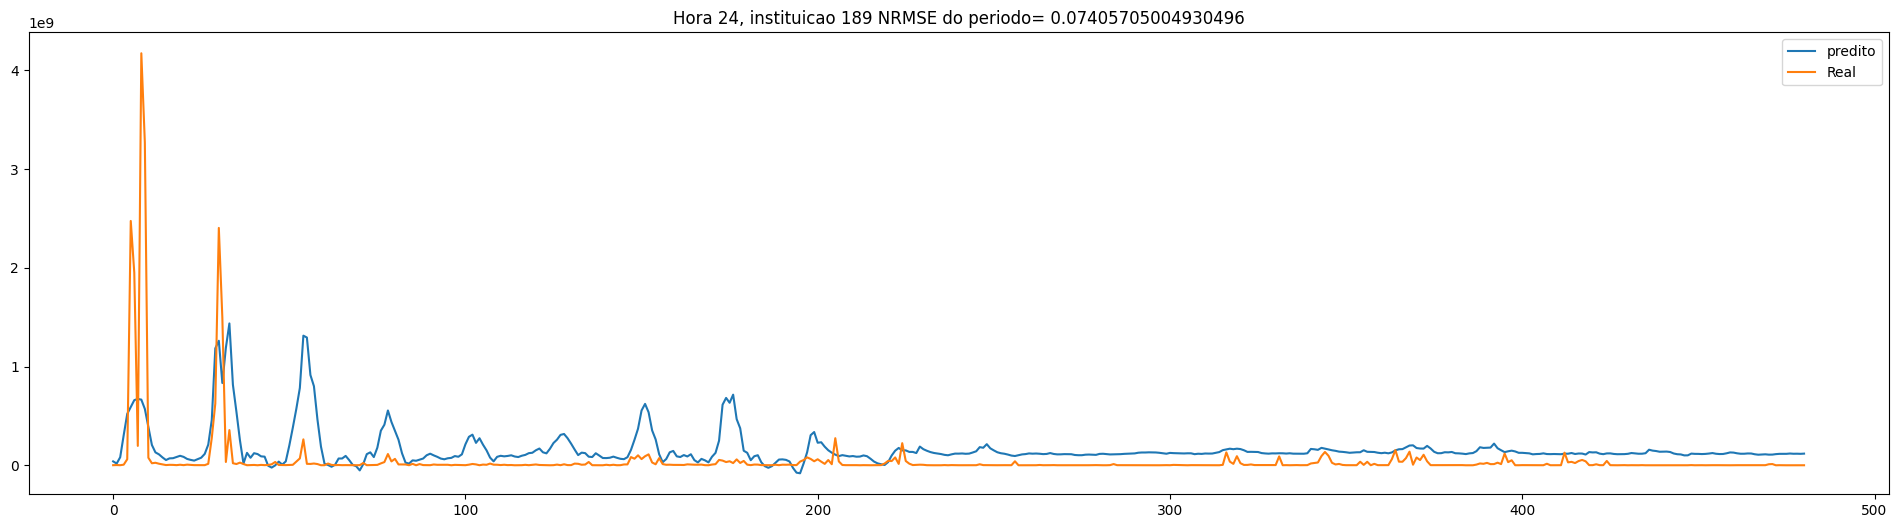

In [222]:
df1 = pd.read_csv("../../RESULTADOS/avaliacao_por_instituicao.csv")
t = 23
i = 189
import matplotlib.pyplot as plt
ids_instituicoes = X_test_h[:, 0]
indices_inst = np.where(ids_instituicoes == i)[0]
predicao = predicoes_sem_escaler["GRU"]["Horario"][indices_inst]
predicao = predicao[:,t]
real = real_sem_escaler["Horario"][indices_inst]
real = real[:,t]
plt.figure(figsize=(24, 6))
nmrse = avaliar_modelo(real.flatten(), predicao.flatten())["NRMSE"]
plt.title(f"Hora {t+1}, instituicao {str(i)} NRMSE do periodo= {nmrse}")
plt.plot(predicao.flatten(), label = "predito")

plt.plot(real.flatten(), label = "Real")
plt.legend()
plt.show()

In [193]:
real

array([4.3192284e+09, 3.8898122e+09, 1.6835369e+10, 6.6694221e+09,
       3.6381742e+09, 1.8306926e+09, 6.9564045e+08, 1.5267378e+09,
       1.4465307e+09, 2.0556225e+09, 2.2045942e+09, 2.7612383e+09,
       8.9181792e+08, 1.2549284e+09, 1.8392658e+09, 3.3290652e+09,
       5.2988390e+09, 3.0740408e+09, 1.8041878e+09, 1.3873091e+08,
       2.5971990e+08], dtype=float32)

In [189]:
X_test_d

array([[ 1.8900000e+02,  3.8173586e-01,  2.5488126e-01, ...,
         1.3717628e-01,  5.6502870e-03,  2.9177396e-03],
       [ 1.8900000e+02,  2.5488126e-01,  2.3600583e-01, ...,
         5.6502870e-03,  2.9177396e-03,  1.0927751e-01],
       [ 1.8900000e+02,  2.3600583e-01,  1.8432933e-01, ...,
         2.9177396e-03,  1.0927751e-01,  5.6185436e-01],
       ...,
       [ 1.0400000e+02,  7.0469819e-02,  1.1294924e-02, ...,
         4.9677512e-01,  5.6500757e-01,  3.9461222e-01],
       [ 1.0400000e+02,  1.1294924e-02, -1.5250631e-02, ...,
         5.6500757e-01,  3.9461222e-01,  2.9179445e-01],
       [ 1.0400000e+02, -1.5250631e-02,  4.9600199e-01, ...,
         3.9461222e-01,  2.9179445e-01,  3.9011143e-02]],
      shape=(3507, 8), dtype=float32)

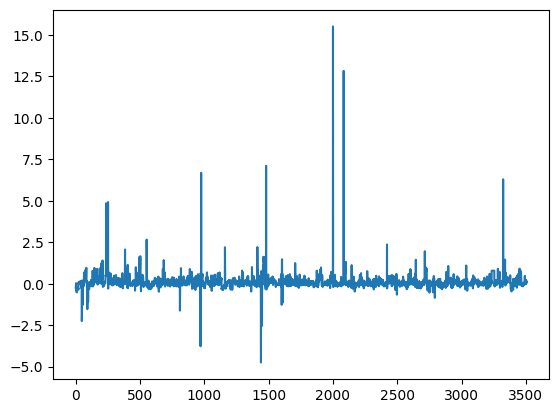

In [177]:
plt.plot(diferencas["GRU"].flatten())

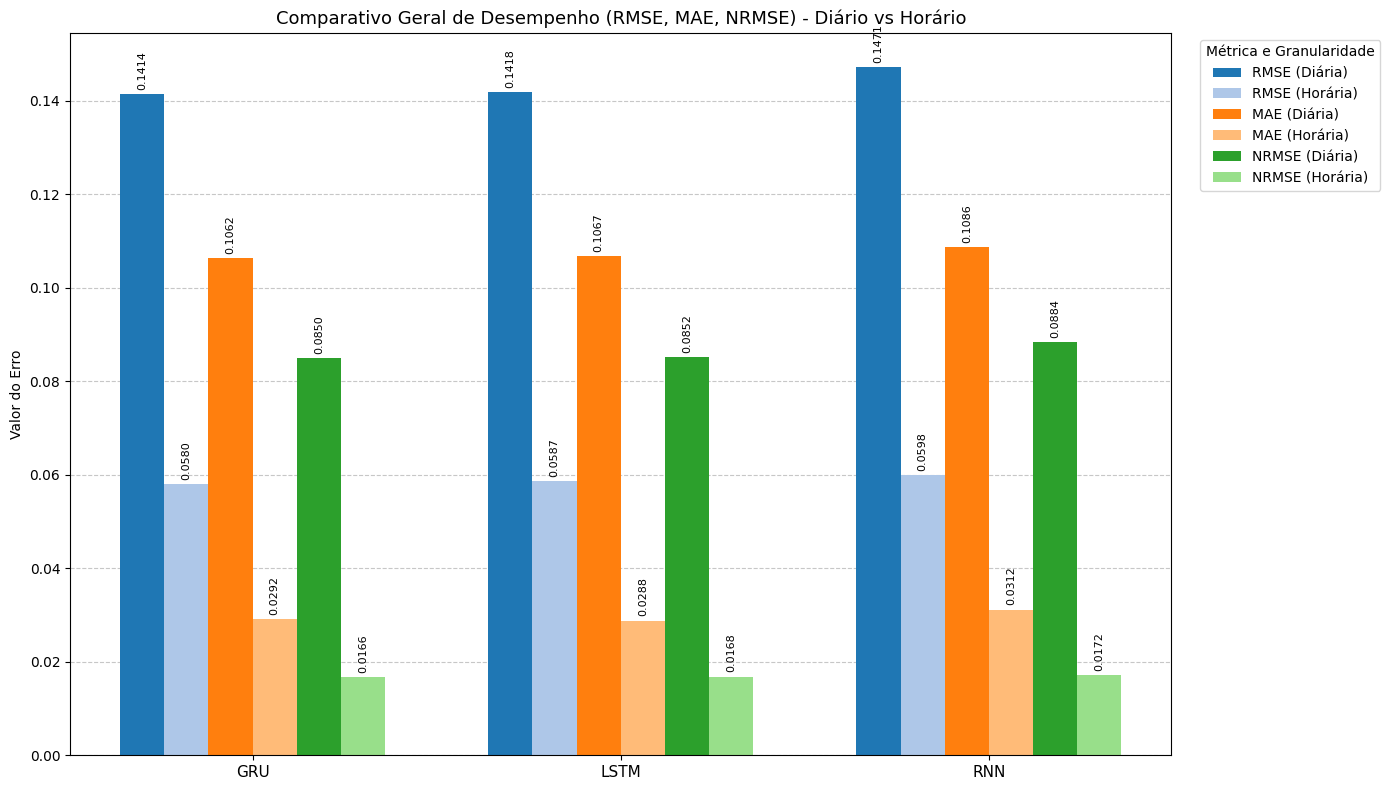

In [226]:
import matplotlib.pyplot as plt
import numpy as np

# A sua estrutura de dicionário (Adicionei o GRU (SEM_ID) com valores aproximados baseados na imagem para ficar completo)


modelos = list(metricas.keys())
metricas_plot = ['RMSE', 'MAE', 'NRMSE'] # sMAPE fica de fora para não quebrar a escala visual

# Cores exatas extraídas da sua imagem de referência
cores = {
    'RMSE': {'Diario': '#1f77b4', 'Horario': '#aec7e8'},   # Azul escuro e claro
    'MAE':  {'Diario': '#ff7f0e', 'Horario': '#ffbb78'},   # Laranja escuro e claro
    'NRMSE': {'Diario': '#2ca02c', 'Horario': '#98df8a'}   # Verde escuro e claro
}

# Configuração do espaçamento das 6 barras
x = np.arange(len(modelos))
largura_barra = 0.12  
offsets = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5] # Multiplicadores para empurrar as barras lateralmente

fig, ax = plt.subplots(figsize=(14, 8)) # Largura maior para caber a legenda fora do quadro

# Loop inteligente para desenhar as 6 barras na ordem correta para cada modelo
idx_offset = 0
for metrica in metricas_plot:
    for granularidade in ['Diario', 'Horario']:
        valores = [metricas[modelo][granularidade][metrica] for modelo in modelos]
        posicao = x + (offsets[idx_offset] * largura_barra)
        
        # Ajuste gramatical para a legenda (Diario -> Diária)
        label = f'{metrica} ({"Diária" if granularidade == "Diario" else "Horária"})'
        cor = cores[metrica][granularidade]
        # 1. Capturamos as barras criadas na variável 'barras'
        barras = ax.bar(posicao, valores, largura_barra, label=label, color=cor)
        
        # 2. Adicionamos os valores no topo com rotação para não sobrepor
        ax.bar_label(barras, padding=3, fmt='%.4f', fontsize=8, rotation=90)
        idx_offset += 1

# Estilização idêntica à imagem
ax.set_ylabel('Valor do Erro')
ax.set_title('Comparativo Geral de Desempenho (RMSE, MAE, NRMSE) - Diário vs Horário', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)

# Configurando o Grid pontilhado atrás das barras
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) 

# Movendo a legenda para fora do gráfico (canto superior direito)
ax.legend(title='Métrica e Granularidade', bbox_to_anchor=(1.02, 1), loc='upper left')

# O tight_layout impede que a legenda seja cortada na hora de salvar
plt.tight_layout()
plt.show()

In [36]:
horas_agregadas["GRU"]

array([0.511021  , 0.49924216, 0.5099691 , ..., 0.5101657 , 0.51504576,
       0.60057425], shape=(80291,), dtype=float32)

In [37]:
y_test_h_df = pd.DataFrame(y_test_h, columns=[f"t+{i}" for i in range(1, y_test_h.shape[1]+1)])
inst = y_test_h_df.iloc[:, -1].values
for i in range(y_pred_h.shape[1]):
    y_test_h_df[f"pred+{i+1}"] = y_pred_h[:, i]
import numpy as np
import pandas as pd

# Quantidade real de passos temporais (excluindo a última coluna que é o ID)
num_passos = y_test_h.shape[1] - 1
coluna_id = f"t+{y_test_h.shape[1]}"

# Nomes das colunas em lote
colunas_pred = [f"pred+{i+1}" for i in range(num_passos)]
colunas_test = [f"t+{i+1}" for i in range(num_passos)]

ids_unicos = np.unique(y_test_h_df[coluna_id].values)

y_pred_h_resized = []
y_test_h_resized = []

for inst_id in ids_unicos:
    # Isola a instituição
    subset = y_test_h_df[y_test_h_df[coluna_id] == inst_id]
    scaler = scalers_hour[str(int(inst_id))]
    
    # 1. Extrai TODAS as colunas ao mesmo tempo e empilha em uma única coluna vertical (-1, 1)
    pred_empilhado = subset[colunas_pred].values.reshape(-1, 1)
    test_empilhado = subset[colunas_test].values.reshape(-1, 1)
    
    # 2. Reverte a escala da matriz inteira de uma vez e achata (.flatten()) para vetor 1D
    pred_invertido = scaler.inverse_transform(pred_empilhado).flatten()
    test_invertido = scaler.inverse_transform(test_empilhado).flatten()
    
    # 3. Adiciona à lista mestre
    y_pred_h_resized.extend(pred_invertido)
    y_test_h_resized.extend(test_invertido)

# 4. Converte o resultado final para arrays limpos do NumPy
y_pred_h_final = np.array(y_pred_h_resized)
y_test_h_final = np.array(y_test_h_resized)

NameError: name 'y_pred_h' is not defined

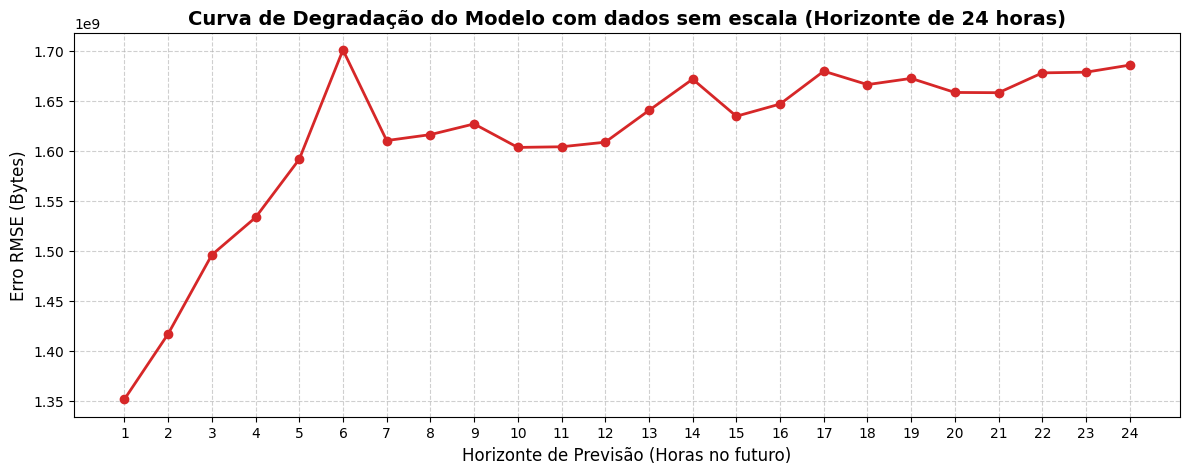

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Supondo que você tenha suas duas matrizes alinhadas:
# y_real_24h -> Matriz (N, 24) com os dados reais
# y_pred_24h -> Matriz (N, 24) com as previsões (ex: predicoes_sem_escaler["GRU"]["Horário"])

passos_futuros = 24
erros_por_horizonte = []

# 1. Calcula o erro separadamente para cada hora no futuro
for t in range(passos_futuros):
    # Pega apenas a coluna 't' de todas as linhas
    real_coluna = real["Horario"][:, t]
    pred_coluna = predicoes["GRU"]["Horario"][:, t]

    # Calcula o RMSE dessa hora específica
    rmse_atual = np.sqrt(mean_squared_error(real_coluna, pred_coluna))
    erros_por_horizonte.append(rmse_atual)

# 2. Plota a Curva de Degradação
plt.figure(figsize=(12, 5))
plt.plot(range(1, passos_futuros + 1), erros_por_horizonte, marker='o', color='#d62728', linewidth=2)

# Estilização
plt.title('Curva de Degradação do Modelo com dados escalonados (Horizonte de 24 horas)', fontsize=14, fontweight='bold')
plt.xlabel('Horizonte de Previsão (Horas no futuro)', fontsize=12)
plt.ylabel('Erro RMSE (Bytes)', fontsize=12)

# Garante que o eixo X mostre de 1 a 24 certinho
plt.xticks(range(1, passos_futuros + 1))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()